In [1]:
import pandas as pd
import pyam

In [31]:

pop = pd.read_csv('/Users/awais/Documents/GitHub/message-ix-canada/data/population/pop_messageca_prov.csv', header=0, sep=',')
gdp = pd.read_csv('/Users/awais/Documents/GitHub/message-ix-canada/data/gdp/openinsights_GDP_2010USD.csv', header=0, sep=',')
rep = pd.read_excel('/Users/awais/Documents/GitHub/message-ix-canada/reporting_outputs/chs_bd.xlsx')
rep1 = pd.read_excel('/Users/awais/Documents/GitHub/message-ix-canada/reporting_outputs/netzero_opt_bd.xlsx')
rep2 = pd.read_excel('/Users/awais/Documents/GitHub/message-ix-canada/reporting_outputs/netzero_pes_bd.xlsx')

In [32]:
rep2['Scenario'].unique()

array(['Netzero-pes'], dtype=object)

In [33]:
rep.drop_duplicates(inplace=True)
rep.dropna(inplace=True)
rep1.drop_duplicates(inplace=True)
rep1.dropna(inplace=True)
rep2.drop_duplicates(inplace=True)
rep2.dropna(inplace=True)
rep['Scenario'] = 'CHS'
df_pyam = pyam.IamDataFrame(rep)
df_pyam1 = pyam.IamDataFrame(rep1)
df_pyam3 = pyam.IamDataFrame(rep2)

gdp = gdp[(gdp['variable'] == 'Input|GDP|PPP') & (gdp['SSP'] == 'SSP2')]
gdp['variable']  = 'GDP'
gdp['model'] = df_pyam.model[0]
gdp['scenario']= df_pyam.scenario[0]
gdp['unit'] = 'billion USD2020'
gdp['variable'] = 'GDP'
gdp = gdp[gdp["region"] != "Canada"]
gdp.drop(columns = ['SSP'],inplace = True )

# GDP Convertions ---
## 1 USD 2010 == 1.19 USD 2020 -- https://www.in2013dollars.com/us/inflation/2010?endYear=2020&amount=1
## 1 USD 2020 ==  1.34 CAD 2020 --  https://www.bankofcanada.ca/rates/exchange/annual-average-exchange-rates/

gdp["value"] = gdp["value"] * 1.45

pop['model'] = df_pyam.model[0]
pop['scenario']= df_pyam.scenario[0]
pop['unit'] = 'million people'
pop['variable'] = 'Population'
pop.rename(columns={"Province": "region", "Population": "value", "Year": "year"}, inplace=True)
pop['value'] = pop['value'] *1e-03
pop = pop[pop["region"] != "Canada"]

pop_netzero = pop.copy()
pop_netzero["scenario"] = "Netzero-opt"

pop_copl = pop.copy()
pop_copl["scenario"] = "Netzero-pes"

gdp_netzero = gdp.copy()
gdp_netzero["scenario"] = "Netzero-opt"

gdp_copl = gdp.copy()
gdp_copl["scenario"] = "Netzero-pes"

rep_with_gdp = [rep["Region"] != "Canada"]

df_gdp = pyam.IamDataFrame(gdp)
df_gdp_netzero = pyam.IamDataFrame(gdp_netzero)
df_pop = pyam.IamDataFrame(pop)
df_pop_netzero = pyam.IamDataFrame(pop_netzero)

df_gdp_copl = pyam.IamDataFrame(gdp_copl)
df_pop_copl = pyam.IamDataFrame(pop_copl)

In [34]:
rep_with_gdp = pyam.concat([df_pyam,df_gdp,df_pyam1,df_pop,df_pop_netzero,df_gdp_netzero,df_gdp_copl,df_pop_copl,df_pyam3])
rep_with_gdp = rep_with_gdp.filter(region = 'Canada', keep=False)

In [36]:
region_abbreviation_map = {
    "Alberta": "AB",
    "British Columbia": "BC",
    "BritishColumbia": "BC",
    "Manitoba": "MB",
    "New Brunswick": "NB",
    "NewBrunswick": "NB",
    "Newfoundland and Labrador": "NL",
    "NewfoundlandandLabrador": "NL",
    "Northwest Territories": "NT",
    "NorthwestTerritories": "NT",
    "Nova Scotia": "NS",
    "NovaScotia": "NS",
    "Nunavut": "NU",
    "Ontario": "ON",
    "Prince Edward Island": "PE",
    "PrinceEdwardIsland": "PE",
    "Quebec": "QC",
    "Saskatchewan": "SK",
    "Yukon": "YK"
}
rep_with_gdp.rename(region = region_abbreviation_map, inplace=True)

In [37]:
rep_with_gdp.scenario

['CHS', 'Netzero-opt', 'Netzero-pes']

In [38]:


# rep_with_gdp.filter(variable ='GDP').convert_unit('USD','Bi-USD',factor = 1e-9)
# Probably need to convert emissions from C-equivalent to CO2-equivalent?
#### ----- #### ---- #### ----- #### ---- #### ----- #### ---- #### ----- #### ---- ####
rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="National", subregions=rep_with_gdp.region, append=True)

rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="Atlantic", subregions=["PE", "NS", "NL", "NB"], append=True)

<Axes: title={'center': 'model: MESSAGEix-CA - region: National - variable: GDP'}, xlabel='Year', ylabel='billion USD2020'>

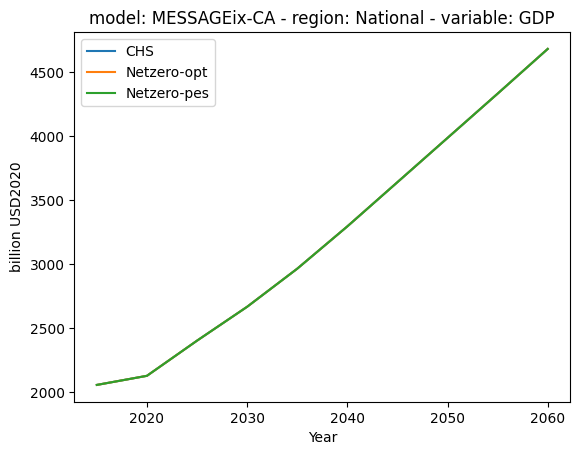

In [39]:
rep_with_gdp.filter(variable = 'GDP', region = 'National').plot()

In [40]:
rep_with_gdp_region = rep_with_gdp.filter(region=["National", "Atlantic","Canada"], keep=False)

In [41]:
final_energy_mj = rep_with_gdp.filter(variable ='Final Energy').convert_unit('PJ/yr','MJ/yr',factor = 1e9)
gdp = rep_with_gdp.filter(variable ='GDP').convert_unit('billion USD2020','USD2020',factor = 1e9)

In [42]:
final_energy_mj.head()

,model,scenario,region,variable,unit,year,value
0,MESSAGEix-CA,CHS,AB,Final Energy,MJ/yr,2025,3.367968e+12
1,MESSAGEix-CA,CHS,AB,Final Energy,MJ/yr,2030,3.814823e+12
2,MESSAGEix-CA,CHS,AB,Final Energy,MJ/yr,2035,3.777779e+12
3,MESSAGEix-CA,CHS,AB,Final Energy,MJ/yr,2040,3.690205e+12
4,MESSAGEix-CA,CHS,AB,Final Energy,MJ/yr,2045,3.576631e+12


In [43]:
fe_gdp = pyam.concat([final_energy_mj,gdp])

In [44]:

fin_energy = fe_gdp.divide('Final Energy','GDP','Final Energy Intensity of GDP',ignore_units=True, axis = 'variable').timeseries()
carbon_intensity = rep_with_gdp.divide('Emissions|Kyoto Gases','GDP','Carbon Intensity',ignore_units=True, axis = 'variable').timeseries()
second_energy_dem = rep_with_gdp.aggregate(variable="Final Energy Demand (Secondary Energy)",components=['Secondary Energy|Electricity', 'Secondary Energy|Gases', 'Secondary Energy|Heat'
                    'Secondary Energy|Hydrogen', 'Secondary Energy|Liquids', 'Secondary Energy|Solids'], method="sum")
elec_supply = rep_with_gdp.aggregate(variable = "Electricity Supply", components=["Secondary Energy|Electricity"])
elec_supply.convert_unit("PJ", "TWh", factor=0.2778)
# shadow_co2 = 
ghg_emissions = rep_with_gdp.aggregate(variable="Total GHG Emissions", components=["Emissions"])
ghg_emissions.convert_unit("Mt C-equivalent", "Mt CO2 eq", 44/12) 



final_df = pyam.concat([rep_with_gdp, fin_energy, carbon_intensity, second_energy_dem, elec_supply, ghg_emissions])


[WARNING] 21:53:57 - pyam.utils: Formatted data is empty.


In [45]:

final_df.divide('Secondary Energy|Electricity|Non-Biomass Renewables', 'Secondary Energy|Electricity','Share of Renewable', append=True)

In [46]:
import pyam
import matplotlib.pyplot as plt
from itertools import cycle
from pyam.plotting import OUTSIDE_LEGEND

In [47]:
final_df_region = final_df.filter(region = ['National','Atlantic','Canada'],keep = False)

In [48]:
vars = [
'Emissions|CO2|Energy|Demand|AFOFI',
'Emissions|CO2|Energy|Demand|Commercial',
'Emissions|CO2|Energy|Demand|Industry',
'Emissions|CO2|Energy|Demand|Other Sector',
'Emissions|CO2|Energy|Demand|Residential',
'Emissions|CO2|Energy|Demand|Transportation',
'Emissions|CO2|Energy|Supply|Electricity',
'Emissions|CO2|Energy|Supply|Gases',
'Emissions|CO2|Energy|Supply|Heat',
'Emissions|CO2|Energy|Supply|Liquids',
'Emissions|CO2|Energy|Supply|Other',
'Emissions|CO2|Energy|Supply|Solids']
# 'Emissions|CO2|Industrial Processes']

In [51]:
final_df.scenario

['CHS', 'Netzero-opt', 'Netzero-pes']

/opt/miniconda3/envs/msg/lib/python3.10/site-packages/pyam/plotting.py:461: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  _rows = pd.concat(


<Axes: title={'center': 'model: MESSAGEix-CA scenario: Netzero-opt region: National'}, xlabel='Year', ylabel='Mt CO2/yr'>

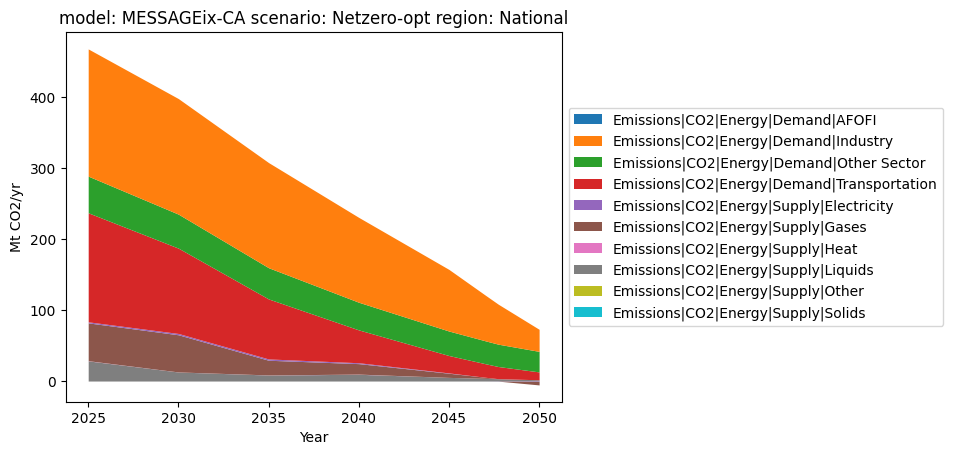

In [52]:
final_df.filter(variable = vars, region = 'National',scenario = 'Netzero-opt', year = [2025,2030,2035,2040,2045,2050]).plot.stack(stack  = 'variable')



/opt/miniconda3/envs/msg/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-CA scenario: CHS region: National'}, xlabel='Year', ylabel='Mt CO2/yr'>

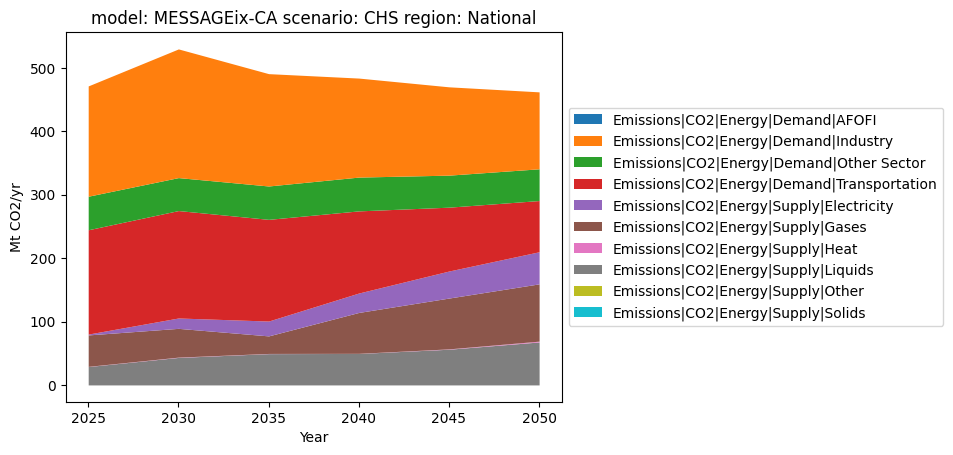

In [ ]:
final_df.filter(variable = vars, region = 'National',scenario = 'CHS', year = [2025,2030,2035,2040,2045,2050]).plot.stack(stack  = 'variable')

In [54]:
import seaborn as sns

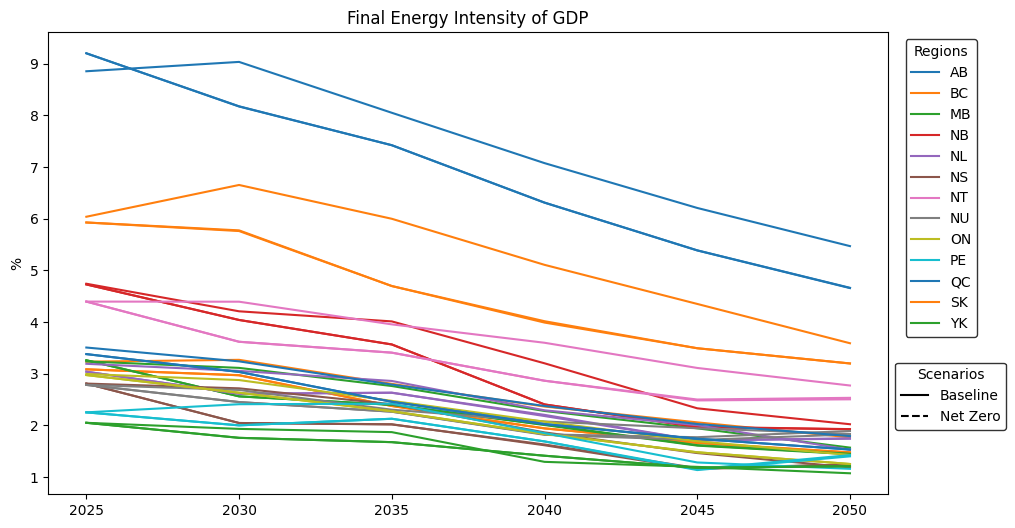

In [55]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyam
import matplotlib.lines as mlines

# Define the selected variable
selected_variable = "Final Energy Intensity of GDP"
df = final_df_region.filter(variable=selected_variable)
yrs = [x for x in final_df_region.year if 2025 <= x <= 2050]

# Function to assign line styles based on scenario names
def assign_linestyle(scenario):
    return "dashed" if "Net Zero" in scenario.lower() else "solid"

# Convert to pandas DataFrame
df_pandas = df.as_pandas()

# Add linestyle based on scenario
df_pandas["linestyle"] = df_pandas["scenario"].apply(assign_linestyle)

# Ensure region names are clean
df_pandas["region_fix"] = df_pandas["region"].str.replace(r'UP\|', '', regex=True)

# Generate unique colors for regions
unique_regions = df_pandas["region_fix"].unique()
color_palette = sns.color_palette("tab10", n_colors=len(unique_regions))
color_mapping = {region_fix: color for region_fix, color in zip(unique_regions, color_palette)}

# Convert back to pyam IamDataFrame
df = pyam.IamDataFrame(df_pandas)

# Iterate over models
for m in df.model:
    model_df = df.filter(model=m, year=yrs)

    # **Increase figure width significantly**
    fig, ax = plt.subplots(figsize=(14, 6))

    # Iterate over regions and plot scenarios for each region with unique colors
    for region in model_df.region:
        for scenario in model_df.scenario:
            sub_df = model_df.filter(region=region, scenario=scenario)

            if sub_df.data.empty:
                continue  # Skip empty plots

            # Get properties
            linestyle = sub_df.data["linestyle"].iloc[0]
            color = color_mapping[region]  # Assign color per region

            # Plot each region with a scenario-specific line style
            ax.plot(
                sub_df["year"],
                sub_df["value"],
                color=color,
                linestyle=linestyle
            )

    # Set title
    ax.set_title(f"{selected_variable}")

    # Create separate legends for regions and line styles
    region_legend = [mlines.Line2D([], [], color=color, label=region) for region, color in color_mapping.items()]
    scenario_legend = [
        mlines.Line2D([], [], color="black", linestyle="-", label="Baseline"),
        mlines.Line2D([], [], color="black", linestyle="--", label="Net Zero")
    ]

    # **Make space for the legend by shrinking the plot area**
    fig.subplots_adjust(left=0.05, right=0.65)  # Leaves space on the right for legends

    # Place region legend **further right** with a **box**
    legend1 = ax.legend(
        handles=region_legend, loc="upper left", bbox_to_anchor=(1.0125, 1),
        title="Regions", ncol=1, frameon=True, edgecolor="black"
    )

    # Place scenario legend **below region legend** with a **box**
    legend2 = ax.legend(
        handles=scenario_legend, loc="upper left", bbox_to_anchor=(1, 0.3),
        title="Scenarios", frameon=True, edgecolor="black"
    )

    ax.add_artist(legend1)  # Ensure both legends appear separately

    # Set Y-axis label with the unit
    # ax.set_ylabel(df_pandas['unit'].unique()[0])
    ax.set_ylabel('%')

    plt.show()


## Map Plot

In [70]:
# Changing Region names 
region_fullname_map = {
    "AB": "Alberta",
    "BC": "BritishColumbia",
    "MB": "Manitoba",
    "NB": "NewBrunswick",
    "NL": "NewfoundlandandLabrador",
    "NT": "NorthwestTerritories",
    "NS": "NovaScotia",
    "NU": "Nunavut",
    "ON": "Ontario",
    "PE": "PrinceEdwardIsland",
    "QC": "Quebec",
    "SK": "Saskatchewan",
    "YK": "Yukon"
}

final_df_region.rename(region = region_fullname_map, inplace=True) 

In [74]:
final_df_region = final_df_region.filter(region = ['Trade_hub','global_trade'],keep = False)

In [75]:
df_plot = final_df_region.filter(variable = 'Secondary Energy|Hydrogen',scenario = 'CHS').timeseries().reset_index()

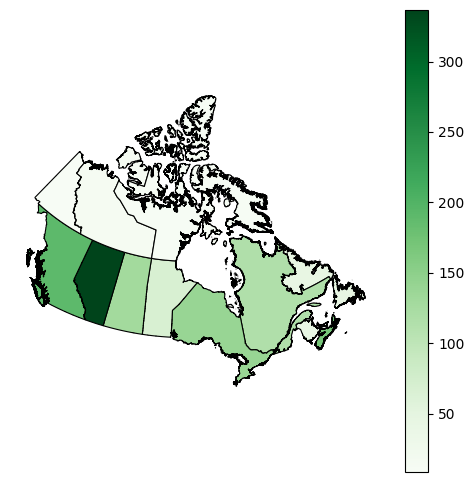

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Path to your shapefile
shapefile_path = '/Users/awais/Documents/GitHub/message-ix-canada/data/delineation/lpr_000b16a_e.shp'

# Load the shapefile
gdf = gpd.read_file(shapefile_path)

# Load and prepare data
df_plot = df_plot[['region', 2050]]
df_plot.rename(columns={2050: 'value'}, inplace=True)
df_plot['value'] = df_plot['value']

# Standardize region names
df_plot['region'] = df_plot['region'].str.replace(' ', '').str.lower()
gdf['PRENAME'] = gdf['PRENAME'].str.replace(' ', '').str.lower()

# Merge with geodataframe
gdf = gdf.merge(df_plot[['region', 'value']], left_on='PRENAME', right_on='region', how='left')

# Fill missing values
gdf['value'] = gdf['value'].fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
# Change colors with cmap option 
gdf.plot(column='value', cmap='Greens', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
ax.set_axis_off()

plt.show()


In [77]:

# Useful indexes (IAMC)
iamc_index = ['model', 'scenario', 'region', 'variable', 'unit']

# Variables
# Chaning the color of variables
color_var = {
    "Electricity": "darkblue",
    "Gases": "brown",
    "Hydrogen": "purple",
    "Liquids": "rosybrown",
}

color_code = {
    "Solids": "#7F7F7F",              # Gray (Coal/solids)
    "Liquids|Oil": "#E69F00",         # Orange (Oil)
    "Liquids|Biomass": "#009E73",     # Green (Biomass)
    "Liquids|Coal": "#4D4D4D",        # Dark Gray (Coal liquids)
    "Liquids|Gas": "#56B4E9",         # Light Blue (Gas liquids)
    "Gases": "#0072B2",               # Blue (Natural gas)
    "Electricity": "#D55E00",         # Red-Orange (Electricity)
    "Heat": "#CC79A7",                # Pink (Heat)
    "Solar": "#F0E442",               # Yellow (Solar)
    "Waste": "#999999",               # Medium Gray (Waste)
    "Geothermal": "#009E73",          # Greenish (Geothermal)
    "Hydrogen": "#CC79A7",            # Pinkish Purple (Hydrogen)
    "Other": "#D3D3D3"                # Light Gray (Other)
}

pyam.run_control().update({"color": {"variable": color_code}})

# Variables useful for synthesis of fuels
useful_vars = {
    "Gases|Electricity": "Electricity",
    "Liquids|Electricity": "Electricity",
    "Gases|Fossil": "Fossil",
    "Liquids|Fossil": "Fossil",
    "Solids|Fossil": "Fossil",
    "Gases|Biomass": "Biomass",
    "Liquids|Biomass": "Biomass",
    "Solids|Biomass": "Biomass",
}
fuel_list = ["Electricity", "Fossil", "Hydrogen", "Biomass", "Solar"]
var_fuel = [
    "Solids",
    "Liquids|Oil",
    "Liquids|Biomass",
    "Liquids|Coal",
    "Liquids|Gas",
    "Gases",
    "Electricity",
    "Heat",
    "Solar",
    "Waste",
    "Geothermal",
    "Hydrogen",
    "Other",
]
# Sectors
sectors = {
    "Transportation": "Transport",
    "Residential and Commercial": "Building",
    "Industry": "Industry",
}

var_sector = [
    # Transport
    'Final Energy|Transportation|Electricity',
    'Final Energy|Transportation|Gases',
    'Final Energy|Transportation|Hydrogen'
    'Final Energy|Transportation|Liquids|Biomass',
    'Final Energy|Transportation|Liquids|Oil',
    'Final Energy|Transportation|Other'
    # Building
    'Final Energy|Residential and Commercial|Electricity',
    'Final Energy|Residential and Commercial|Gases',
    'Final Energy|Residential and Commercial|Heat',
    'Final Energy|Residential and Commercial|Hydrogen',
    'Final Energy|Residential and Commercial|Liquids'
    'Final Energy|Residential and Commercial|Other',
    'Final Energy|Residential and Commercial|Solids'
    # Industry
    'Final Energy|Industry|Electricity',
 'Final Energy|Industry|Gases',
 'Final Energy|Industry|Heat',
 'Final Energy|Industry|Hydrogen',
 'Final Energy|Industry|Liquids',
 'Final Energy|Industry|Other',
 'Final Energy|Industry|Solids' 
    ]

In [78]:
df_ca = final_df.filter(region = 'National')

In [ ]:
df_ca.filter(variable = 'Final Energy|')

['CHS', 'Netzero-opt', 'Netzero-pes']

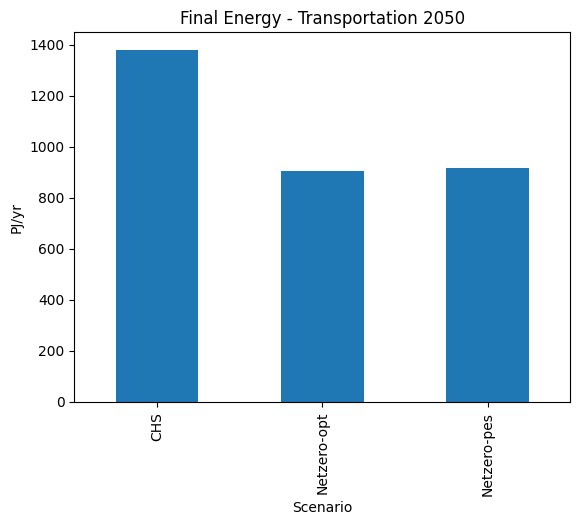

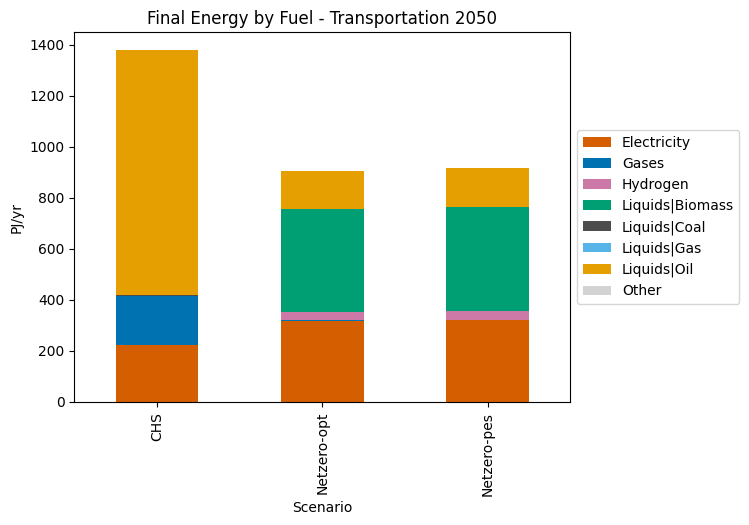

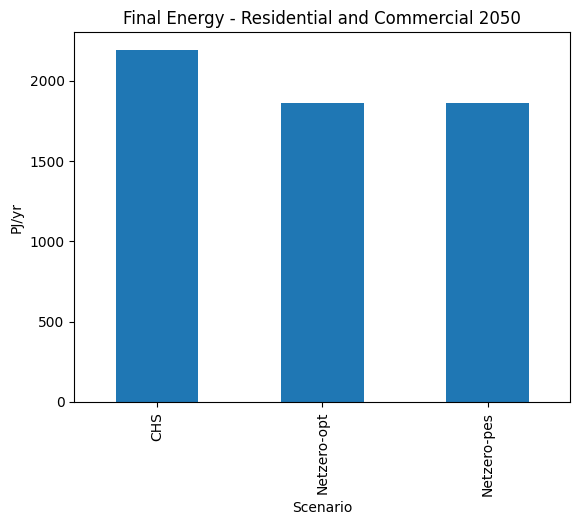

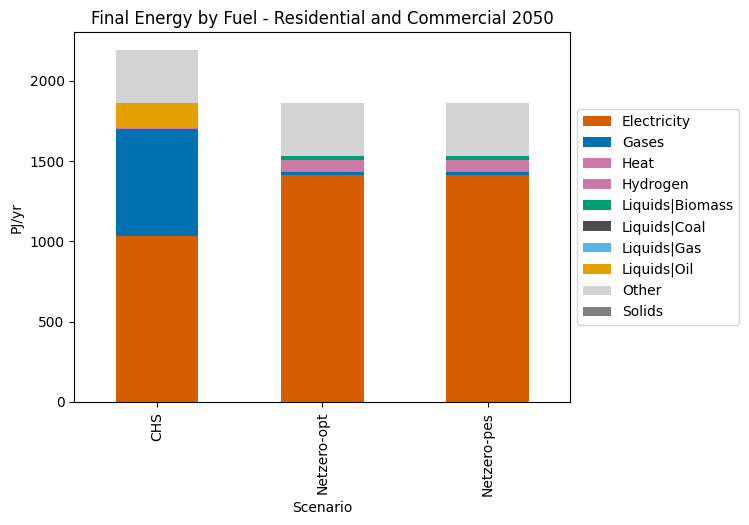

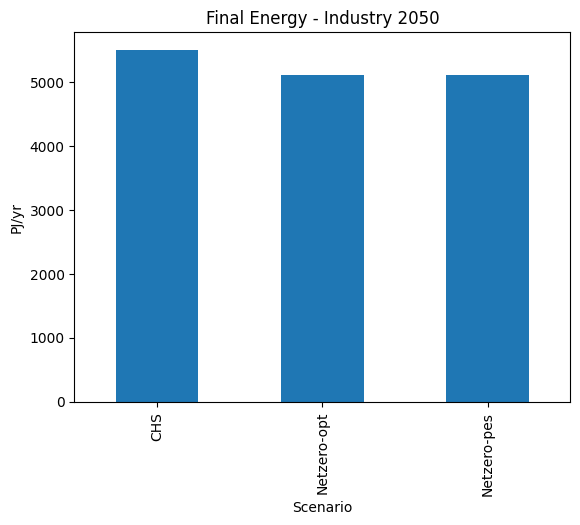

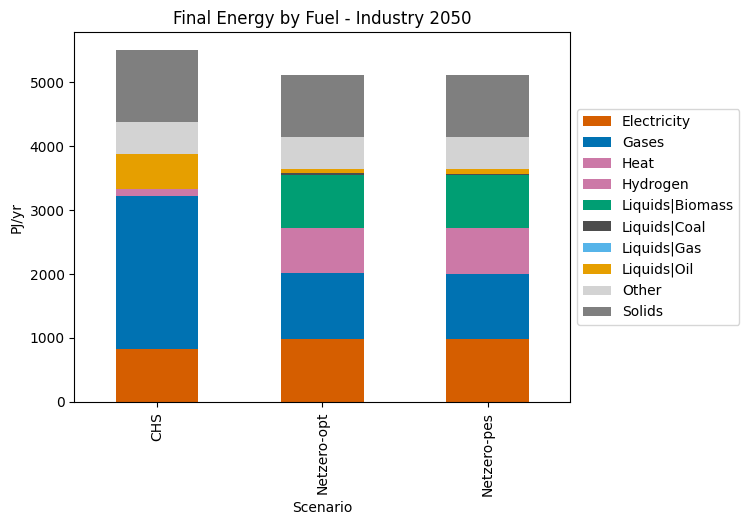

In [82]:
yr = 2050
scenario_order = ["CHS", "Netzero-opt", "Netzero-pes"]  # desired order

for sect in sectors.keys():
    # Filter with scenario order explicitly
    df1 = df_ca.filter(
        variable=["Final Energy|" + sect],
        year=yr,
        scenario=scenario_order
    )

    ax = df1.plot.bar(
        x="scenario",
        title=f"Final Energy - {sect} {yr}",
        legend=False,
    )

    # For fuels, same approach
    df = df_ca.filter(
        variable=["Final Energy|" + sect + "|" + x for x in var_fuel],
        year=yr,
        scenario=scenario_order
    )

    ax = df.rename(variable={
        x: x.split(sect + "|")[1] for x in df.variable}).plot.bar(
        x="scenario",
        title=f"Final Energy by Fuel - {sect} {yr}",
        legend=True,
        stacked=True,
    )


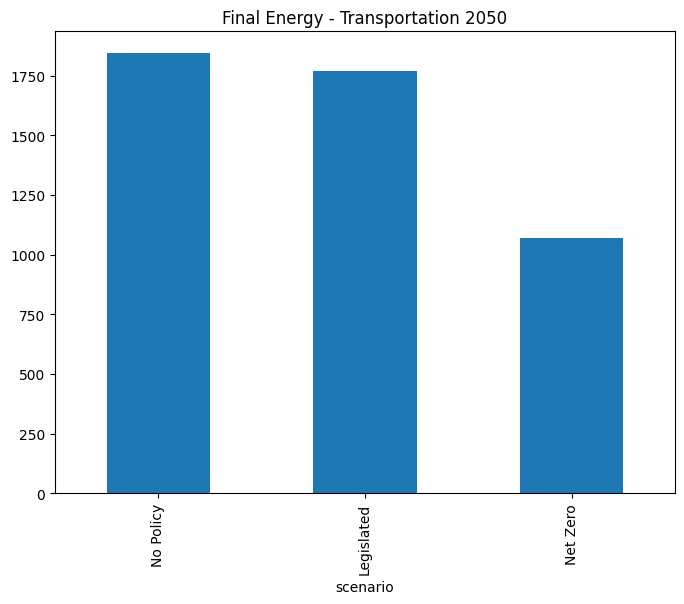

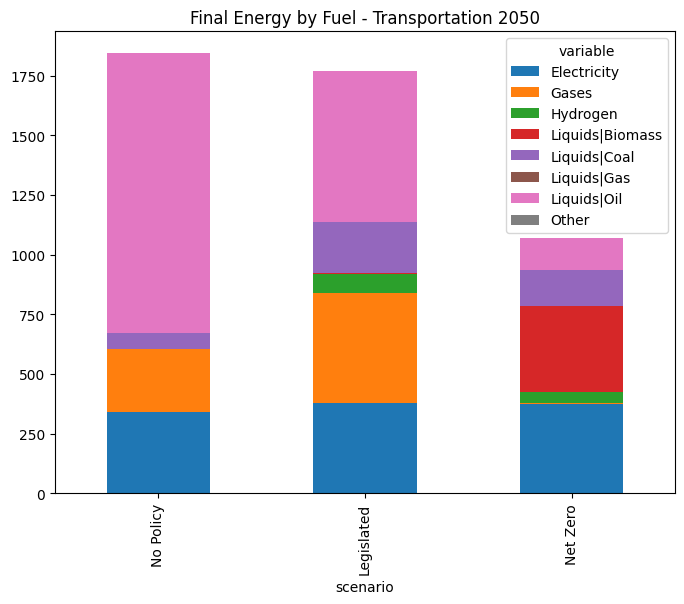

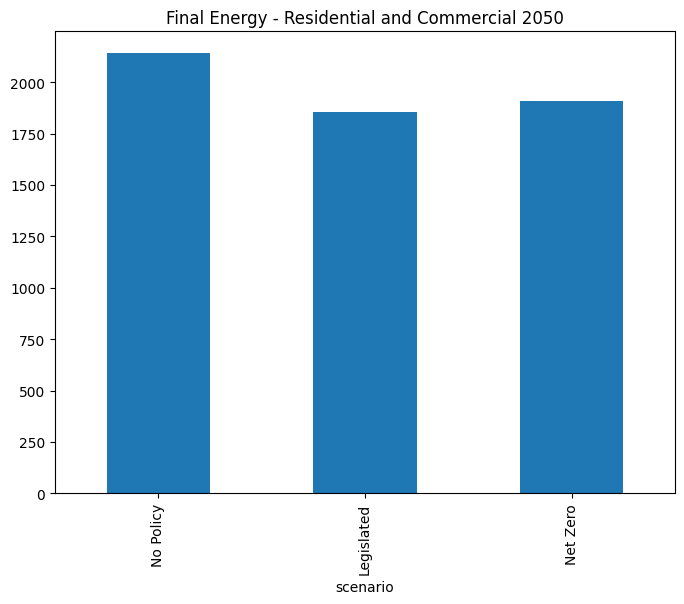

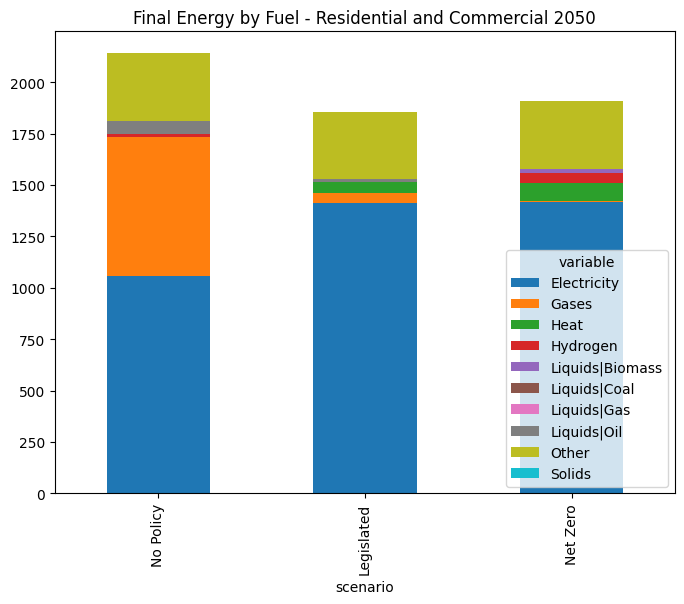

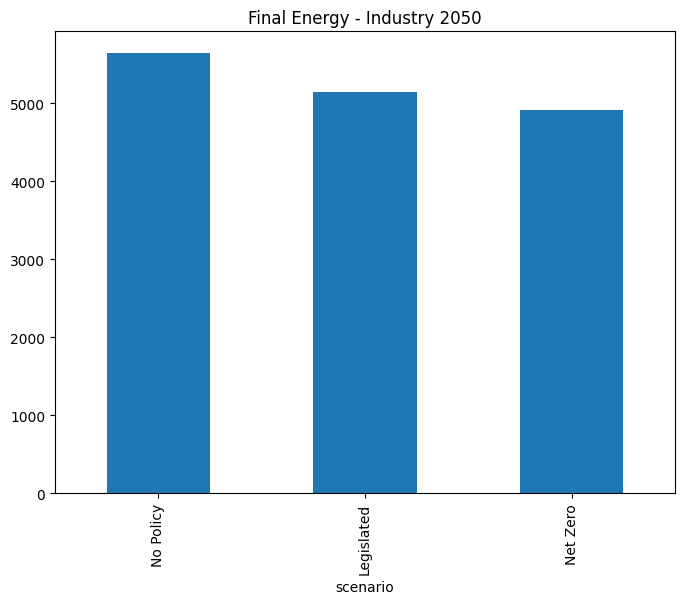

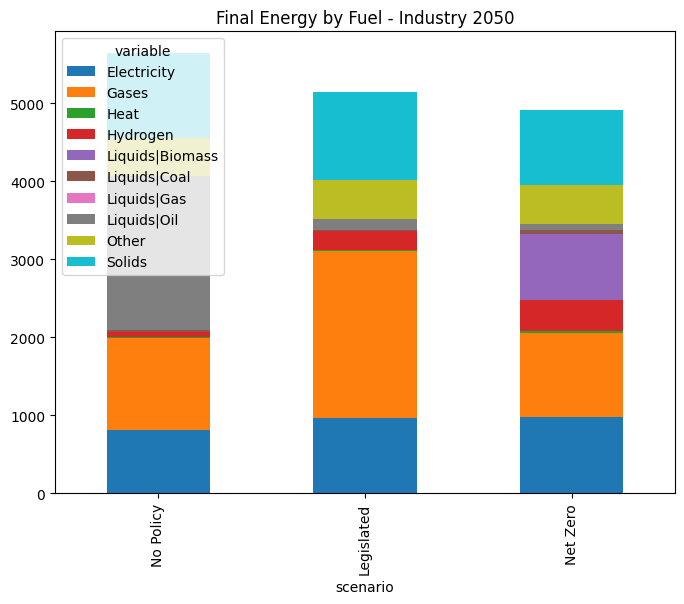

In [74]:
yr = 2050
scenario_order = ["No Policy", "Legislated", "Net Zero"]

for sect in sectors.keys():
    # Extract timeseries as pandas DataFrame
    df1_pd = df_ca.filter(
        variable=["Final Energy|" + sect],
        year=yr
    ).timeseries()

    # Reset index to columns
    df1_pd = df1_pd.reset_index()

    # Filter only scenarios of interest
    df1_pd = df1_pd[df1_pd['scenario'].isin(scenario_order)]

    # Make scenario categorical with desired order
    df1_pd['scenario'] = pd.Categorical(df1_pd['scenario'], categories=scenario_order, ordered=True)

    # Sort by scenario order
    df1_pd = df1_pd.sort_values('scenario')

    # Plot total final energy bars
    ax = df1_pd.plot.bar(
        x='scenario',
        y=yr,
        title=f"Final Energy - {sect} {yr}",
        legend=False,
        figsize=(8,6)
    )

    # Similarly for fuels
    df_fuel_pd = df_ca.filter(
        variable=["Final Energy|" + sect + "|" + x for x in var_fuel],
        year=yr
    ).timeseries().reset_index()

    df_fuel_pd = df_fuel_pd[df_fuel_pd['scenario'].isin(scenario_order)]
    df_fuel_pd['scenario'] = pd.Categorical(df_fuel_pd['scenario'], categories=scenario_order, ordered=True)
    df_fuel_pd = df_fuel_pd.sort_values('scenario')

    # Rename variables to just fuel part
    df_fuel_pd['variable'] = df_fuel_pd['variable'].apply(lambda x: x.split(sect + "|")[-1])

    # Pivot so fuels become columns
    df_pivot = df_fuel_pd.pivot(index='scenario', columns='variable', values=yr)

    # Plot stacked bar
    ax = df_pivot.plot.bar(
        stacked=True,
        title=f"Final Energy by Fuel - {sect} {yr}",
        figsize=(8,6)
    )


In [97]:

selected_sector = "Residential and Commercial"
selected_variable = "Final Energy|" + selected_sector
# selected_scenario = "Electrification|High eff."

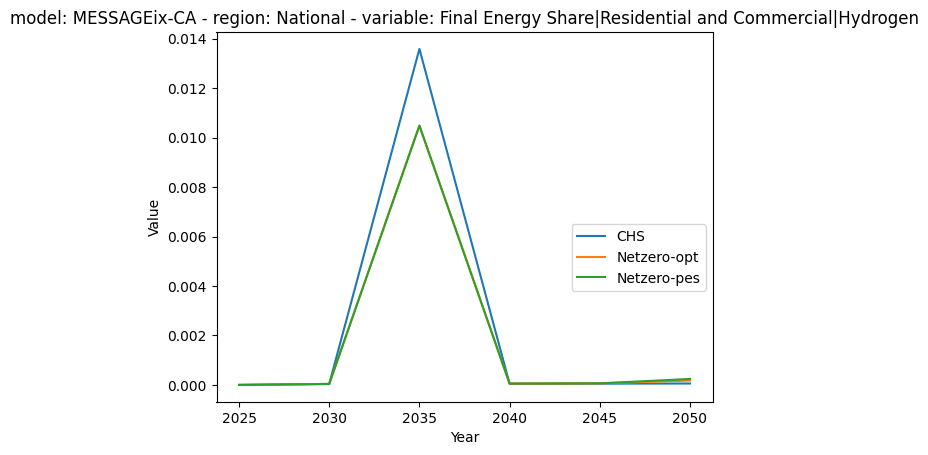

In [98]:
# %% 3.7) Calculating the shares
# 3.7.1) Calculating a share (e.g., share of hydrogen from total final energy)
df = df_ca.filter(variable="Final Energy|" + selected_sector + "*")
share = df.divide(
    "Final Energy|" + selected_sector + "|Hydrogen",  # nominator
    "Final Energy|" + selected_sector,  # denomanitor
    "Final Energy Share|"
    + selected_sector
    + "|Hydrogen",  # new variable name for share
)
for m in df.model:
    # Visualization
    ax = share.filter(year=range(2010, 2051), model=m).plot(
        legend=OUTSIDE_LEGEND["right"]
    )

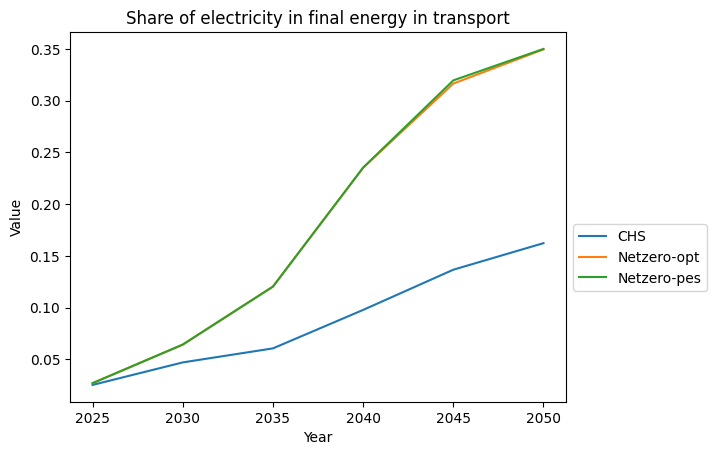

In [85]:

# 3.7.2) Calculating and comparing a share for several models and scenarios
df = df_ca.filter(year=range(2010, 2051))
share = df.divide(
    "Final Energy|Transportation|Electricity",  # nominator
    "Final Energy|Transportation",  # denomanitor
    "Final Energy Share|Transportation|Electricity",  # new variable name for share
)

# Visualization
ax = share.plot(
    title="Share of electricity in final energy in transport",
    legend=OUTSIDE_LEGEND["right"],
    color="scenario",
)


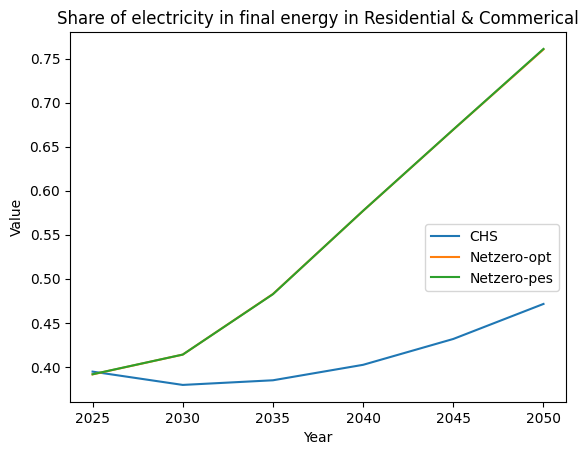

In [86]:

# 3.7.2) Calculating and comparing a share for several models and scenarios
df = df_ca.filter(year=range(2010, 2051))
share = df.divide(
    "Final Energy|Residential and Commercial|Electricity",  # nominator
    "Final Energy|Residential and Commercial",  # denomanitor
    "Final Energy Share|Residential and Commercial|Electricity",  # new variable name for share
)

# Visualization
ax = share.plot(
    title="Share of electricity in final energy in Residential & Commerical",
    legend=OUTSIDE_LEGEND["right"],
    color="scenario",
)


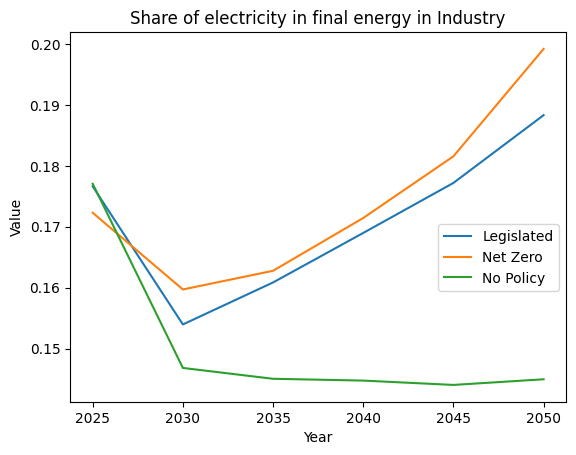

In [81]:

# 3.7.2) Calculating and comparing a share for several models and scenarios
df = df_ca.filter(year=range(2010, 2051))
share = df.divide(
    "Final Energy|Industry|Electricity",  # nominator
    "Final Energy|Industry",  # denomanitor
    "Final Energy Share|Industry|Electricity",  # new variable name for share
)

# Visualization
ax = share.plot(
    title="Share of electricity in final energy in Industry",
    legend=OUTSIDE_LEGEND["right"],
    color="scenario",
)


'Final Energy|Residential and Commercial'

In [99]:
# %% 3.8) Calculating shares for a few commodities in different sectors
commodity_list = ["Electricity", "Hydrogen", "Gases"]
df = final_df

# Calculating shares in a loop for each sector
shares = []
for sec, scen in sectors.items():
    for comm in commodity_list:
        # Calculating share
        share = df.divide(
            "Final Energy|" + sec + "|" + comm,  # nominator
            "Final Energy|" + sec,  # denomanitor
            "Final Energy Share|" + sec + "|" + comm,  # new variable name for share
        )

        # Putting DH at the end of scenarios
        rename_map = {
            s: s.replace("DH", "RC-DH")
            for s in share.scenario
        }
        share = share.rename(scenario=rename_map)

        # Excluding REMIND mismtahced model names
        exclude = [x for x in sectors.values() if x != sectors[sec]]
        for ex in exclude:
            share = share.filter(scenario="WP2 " + ex + "*", keep=False)

        shares.append(share)

df_sh = pyam.concat(shares)

In [100]:
df_sh.scenario

['CHS', 'Netzero-opt', 'Netzero-pes']

In [88]:
import numpy as np

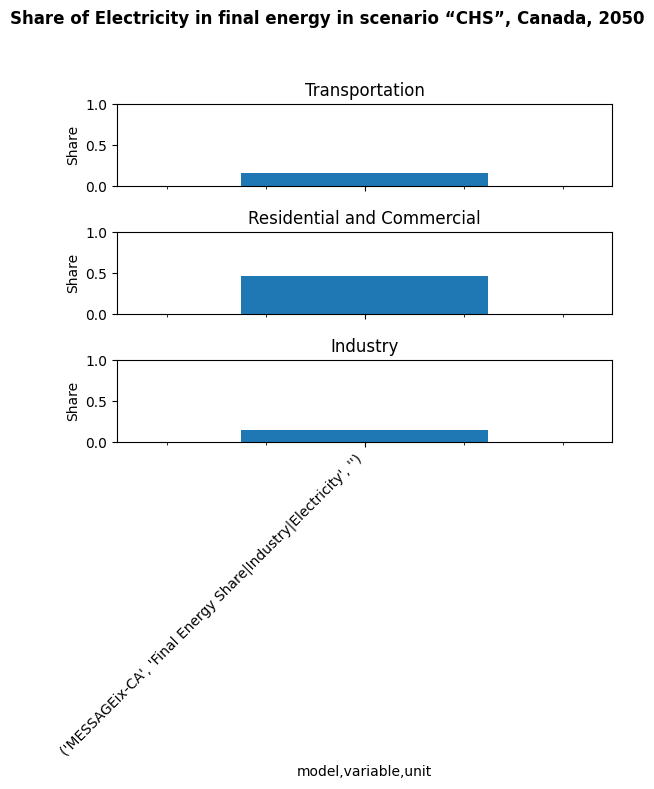

In [93]:
import matplotlib.pyplot as plt

yr = 2050
commodity = "Electricity"
scen = "CHS"  # your single scenario
fig, axes = plt.subplots(3, 1, figsize=(6, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.4)
fig.suptitle(
    f"Share of {commodity} in final energy in scenario “{scen}”, Canada, {yr}",
    fontweight="bold",
)

for ax, (sector_name, _) in zip(axes, sectors.items()):
    # 1) filter to the single scenario
    df_single = df_sh.filter(
        variable=f"Final Energy Share|{sector_name}|{commodity}",
        year=yr,
        scenario=scen
    )
    # 2) convert to a Series indexed by model
    series = df_single.timeseries().droplevel([1, 2], axis=0)  
    #    ^ remove (scenario, year) levels, leaving model → share

    # --- BAR CHART ---
    series.plot.bar(ax=ax)
    ax.set_title(sector_name)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")
    ax.get_legend().remove()

    # --- OR, DOT SCATTER INSTEAD --- 
    # ax.scatter(series.index, series.values, s=50)
    # for i, v in enumerate(series.values):
    #     ax.text(i, v + 0.02, f"{v:.2f}", ha="center")

axes[-1].set_xticklabels(series.index, rotation=45, ha="right")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


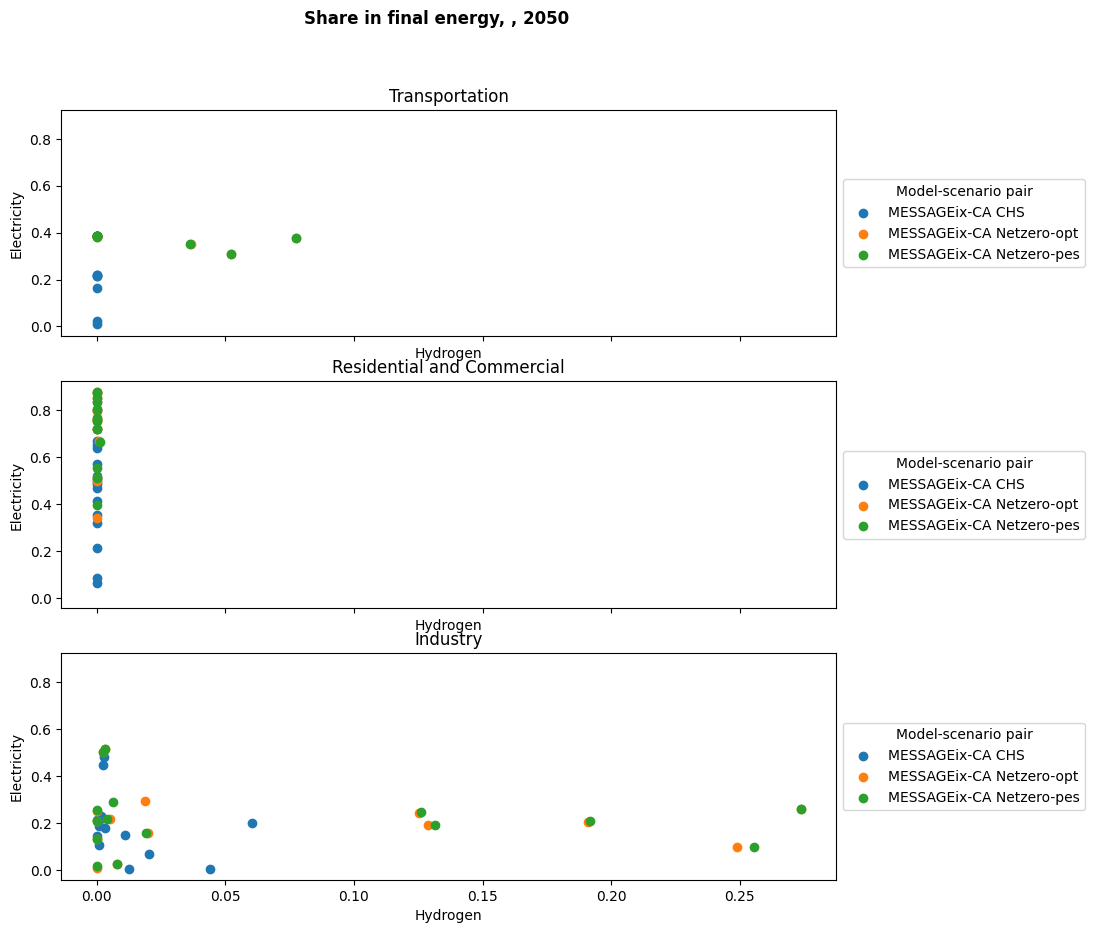

In [ ]:
# %% 3.13) Plotting share of two commodities against each other for model-scenario pairs
com1 = "Hydrogen"
com2 = "Electricity"
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.2)
fig.suptitle("Share in final energy, "  + ", " + str(yr), fontweight="bold")

# Plotting in a for loop for each sector
for x, (se, ax) in enumerate(zip(sectors.keys(), axes.reshape(-1))):
    df_sh.filter(year=yr).plot.scatter(
        ax=ax,
        title=se,
        color="scenario",
        marker="region",
        x="Final Energy Share|" + se + "|" + com1,
        y="Final Energy Share|" + se + "|" + com2,
    )
    # Labels and legend
    ax.set_xlabel(com1), ax.set_ylabel(com2)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Model-scenario pair")

In [ ]:
df

In [107]:
df_sh = df_sh.filter(region = ['Atlantic','National'],keep = False)

In [113]:
sectors

{'Transportation': 'Transport',
 'Residential and Commercial': 'Building',
 'Industry': 'Industry'}

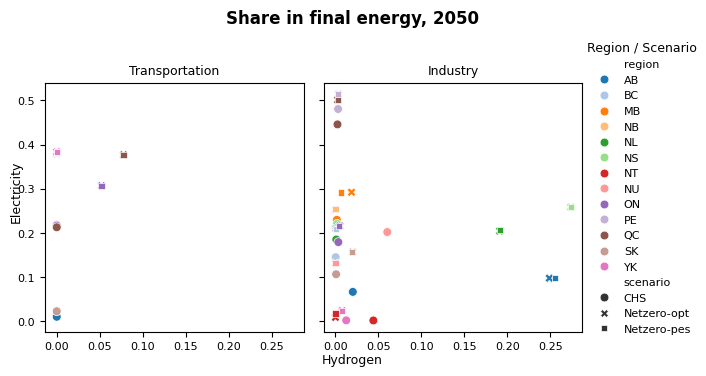

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1) Define your year, commodities, and sectors
# ------------------------------------------------------------
yr   = 2050
com1 = "Hydrogen"
com2 = "Electricity"
sectors = {
    "Transportation": "Transport",
    "Industry":       "Industry"
}

# ------------------------------------------------------------
# 2) Filter the Pyam IamDataFrame by year
# ------------------------------------------------------------
df_year = df_sh.filter(year=yr)

# ------------------------------------------------------------
# 3) Convert to a “long” pandas DataFrame & pivot to wide
# ------------------------------------------------------------
df_long = df_year.data.reset_index()
df_wide = (
    df_long
    .pivot_table(
        index=["model", "scenario", "region"],
        columns="variable",
        values="value"
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4) Build a unique 13‐color palette for “region”
# ------------------------------------------------------------
unique_regions = sorted(df_wide["region"].unique())
n_regions = len(unique_regions)  # should be 13

# Use “tab20” (which has 20 distinct colors) and take the first n_regions
base_palette = sns.color_palette("tab20", n_colors=n_regions)
palette_dict = {region: base_palette[i] for i, region in enumerate(unique_regions)}

# ------------------------------------------------------------
# 5) Create a 1×2 grid (two subplots side by side)
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(7, 3.5),
    sharex=True,
    sharey=True
)
fig.suptitle(f"Share in final energy, {yr}", fontweight="bold", y=1.02)

for idx, sect in enumerate(sectors.keys()):
    ax   = axes[idx]
    col1 = f"Final Energy Share|{sect}|{com1}"
    col2 = f"Final Energy Share|{sect}|{com2}"
    
    # Confirm those columns exist
    missing = [c for c in (col1, col2) if c not in df_wide.columns]
    if missing:
        raise ValueError(f"Missing columns for sector '{sect}': {missing}")
    
    show_legend = (idx == 0)
    
    sns.scatterplot(
        data=df_wide,
        x=col1,
        y=col2,
        hue="region",
        style="scenario",
        palette=palette_dict,
        s=40,
        ax=ax,
        legend="brief" if show_legend else False
    )
    
    ax.set_title(sect, fontsize=9)
    ax.tick_params(axis="both", which="major", labelsize=8)
    ax.grid(False)
    ax.set_xlabel("")  # remove individual subplot labels
    ax.set_ylabel("")

# ------------------------------------------------------------
# 6) Extract legend handles & labels from first subplot, then place one combined legend
# ------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()

fig.legend(
    handles,
    labels,
    loc="center right",
    title="Region / Scenario",
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

# ------------------------------------------------------------
# 7) Add common X and Y labels at the figure‐level
# ------------------------------------------------------------
fig.text(
    0.5,
    0.02,
    com1,           # “Hydrogen”
    ha="center",
    va="center",
    fontsize=9
)
fig.text(
    0.02,
    0.5,
    com2,           # “Electricity”
    ha="center",
    va="center",
    rotation="vertical",
    fontsize=9
)

# ------------------------------------------------------------
# 8) Final layout adjustment
# ------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space on the right for the legend
plt.show()


In [99]:

vars_elec = ['Investment|Energy Supply|CO2 Transport and Storage',
 'Investment|Energy Supply|Electricity','Investment|Energy Supply|Other','Investment|Energy Supply|Liquids','Investment|Energy Supply|Heat',
 'Investment|Energy Supply|Hydrogen',]

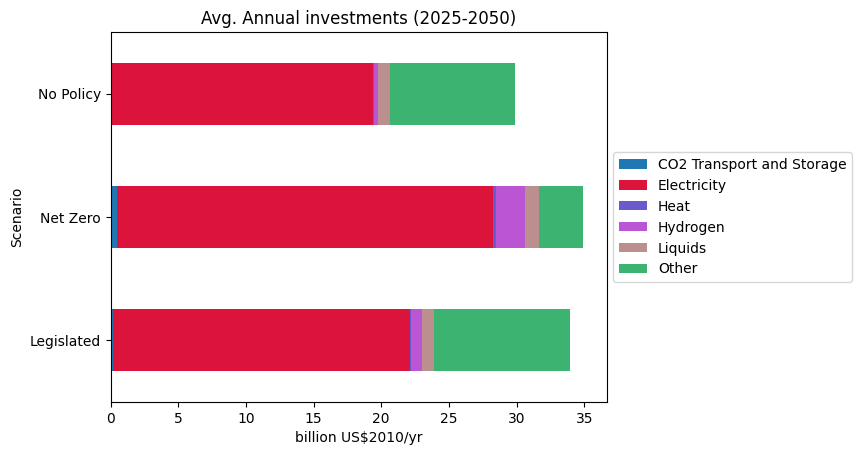

In [111]:
# %% 3.6) Plot data in the stacked bar format for all scenarios of a certain model

yr = 2052
d = df_inv.filter(
variable=vars_elec,
year=yr,
region = 'National'
)
# Rename variables for the legend
rename_map = {
    v: v.replace("Investment|Energy Supply|", "") for v in d.variable
}
ax = d.rename(variable=rename_map).plot.bar(
    stacked=True, x="scenario", orient="h",
    title=f"Avg. Annual investments (2025-2050)")


In [102]:
df_ca = df_ca.filter(variable = vars_elec, region = 'National').timeseries().reset_index()

In [103]:
# Compute the 20 sum for years 2020 to 2050
df_ca[2051] = df_ca.loc[:, 2025:2050].sum(axis=1)
# Compute the cumulative sum for years 2020 to 2050
df_ca[2052] = df_ca.loc[:, 2025:2050].mean(axis=1)
df_ca[2051] = df_ca[2051] *5
df_inv = pyam.IamDataFrame(df_ca)

In [304]:
# Plot data of fuels in the stacked bar format
df = df_ca.filter(
    variable=["Final Energy|" + 'Residential and Commercial' + "|" + x for x in var_fuel],
    year=yr,
)

In [314]:
final_df.filter(variable = 'Investment*').timeseries().to_csv('investment.csv')

In [218]:
df_pandas['unit'].unique()[0]


'PJ/yr'

In [142]:

data = df.filter( variable="Primary Energy|*", region="World"
)

data.plot.stack(title=scenario)
plt.legend(loc=1)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [3]:

final_df.to_csv("model/output/reports/Formatted_Report.csv")

# For searching up 
df_pyam.filter(variable = 'Emissions|*').variable


In [59]:
df_pyam.scenario

['BAU', 'NZ', 'NZ-OPT', 'NZ-PES']

In [61]:
df_pyam_baseline = df_pyam.filter(scenario='BAU')
df_pyam_netzero = df_pyam.filter(scenario = 'NZ')
df_pyam_netzero_opt = df_pyam.filter(scenario = 'NZ-OPT')
df_pyam_netzero_pes = df_pyam.filter(scenario = 'NZ-PES')

df =df_pyam_baseline.as_pandas()
df['value'] = df['value'].astype(float)
df['model'] = 'MESSAGEix-Canada'
df.rename(columns={'year':'time'}, inplace=True)
df.to_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/output_pyam_baseline.csv')

df =df_pyam_netzero.as_pandas()
df['value'] = df['value'].astype(float)
df['model'] = 'MESSAGEix-Canada'
df.rename(columns={'year':'time'}, inplace=True)
df.to_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/output_pyam_netzero.csv')

df =df_pyam_netzero_opt.as_pandas()
df['value'] = df['value'].astype(float)
df['model'] = 'MESSAGEix-Canada'
df.rename(columns={'year':'time'}, inplace=True)
df.to_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/output_pyam_netzero_opt.csv')

df =df_pyam_netzero_pes.as_pandas()
df['value'] = df['value'].astype(float)
df['model'] = 'MESSAGEix-Canada'
df.rename(columns={'year':'time'}, inplace=True)
df.to_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/output_pyam_netzero_pes.csv')

## Markdown for Pyam 

In [4]:
df1 = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/MESSAGEix-CA_baseline.xlsx')
df1['Scenario'] = 'BAU'
df2 = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/MESSAGEix-CA_netzero.xlsx')
df2['Scenario'] = 'NZ'
df3 = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/MESSAGEix-CA_netzero_opt.xlsx')
df3['Scenario'] = 'NZ-OPT'
df4 = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/output/MESSAGEix-CA_netzero_pes.xlsx')
df4['Scenario'] = 'NZ-PES'
df = pd.concat([df1,df2,df3,df4])
# df.loc[:, 2020:2060] = df.loc[:, 2020:2060].abs()
df = df.dropna(subset=['Region'])
df = df.drop_duplicates(subset=  ['Model',   'Region', 'Scenario',
           'Unit', 'Variable'])
# df = df[~df['Variable'].isin(var_lis)]
df_pyam = pyam.IamDataFrame(df)

In [5]:

gdp = pd.read_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/data/gdp/gdp_messageca_prov.csv', header=0, sep=',')

# GDP Convertions ---
## 1 USD 2010 == 1.19 USD 2020 -- https://www.in2013dollars.com/us/inflation/2010?endYear=2020&amount=1
## 1 USD 2020 ==  1.34 CAD 2020 --  https://www.bankofcanada.ca/rates/exchange/annual-average-exchange-rates/

GDP2020 = gdp["GDP"] * 1.19 * 1.34

gdp["GDP"] = GDP2020


gdp['model'] = df_pyam.model[0]
gdp['scenario']= df_pyam.scenario[0]
gdp['unit'] = 'CAD'
gdp['variable'] = 'GDP'
gdp.rename(columns={"Province": "region", "GDP": "value", "Year": "year"}, inplace=True)

gdp = gdp[gdp["region"] != "Canada"]

In [6]:
df_gdp = pyam.IamDataFrame(gdp)

In [7]:
df_pyam.filter(region = 'Canada',keep = False,inplace = True)

<Axes: title={'center': 'model: MESSAGEix-CA - region: Ontario - variable: Emissions|Kyoto Gases'}, xlabel='Year', ylabel='Mt CO2-equiv/yr'>

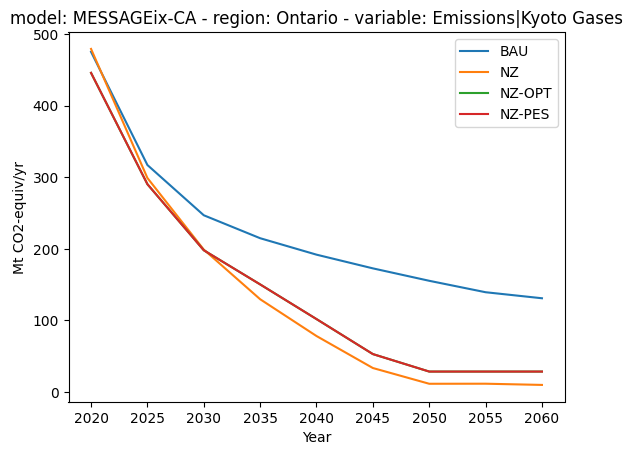

In [69]:
df_pyam.filter(variable = 'Emissions|Kyoto Gases*',region = 'Ontario').plot()

In [8]:

rep_with_gdp = pyam.concat([df_pyam,df_gdp])
rep_with_gdp.filter(variable ='Final Energy').convert_unit('PJ','MJ',factor = 1e-3)
# rep_with_gdp.filter(variable ='Final Energy').convert_unit('CAD','Bi-CAD',factor = 1e-9)
# Probably need to convert emissions from C-equivalent to CO2-equivalent?
#### ----- #### ---- #### ----- #### ---- #### ----- #### ---- #### ----- #### ---- ####
rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="National", subregions=rep_with_gdp.region, append=True)
rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="Atlantic", subregions=["PrinceEdwardIsland", "NovaScotia", "NewfoundlandandLabrador", "NewBrunswick"], append=True)



In [ ]:
rep_with_gdp.filter(variable = 'Final Energy|Transport*',region = 'National', scenario = 'BAU').variable

] 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases',
 'Final Energy|Transportation|Gases|Shipping',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Hydrogen|Shipping',
 'Final Energy|Transportation|Liquids',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Biomass|Shipping',
 'Final Energy|Transportation|Liquids|Coal',
 'Final Energy|Transportation|Liquids|Coal|Shipping',
 'Final Energy|Transportation|Liquids|Gas',
 'Final Energy|Transportation|Liquids|Oil',
 'Final Energy|Transportation|Liquids|Oil|Shipping',
 'Final Energy|Transportation|Liquids|Oil|Shipping|Fuel Oil',
 'Final Energy|Transportation|Liquids|Oil|Shipping|Light Oil',
 'Final Energy|Transportation|Other']

['Final Energy|Transportation',
 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases',
 'Final Energy|Transportation|Gases|Shipping',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Hydrogen|Shipping',
 'Final Energy|Transportation|Liquids',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Biomass|Shipping',
 'Final Energy|Transportation|Liquids|Coal',
 'Final Energy|Transportation|Liquids|Coal|Shipping',
 'Final Energy|Transportation|Liquids|Gas',
 'Final Energy|Transportation|Liquids|Oil',
 'Final Energy|Transportation|Liquids|Oil|Shipping',
 'Final Energy|Transportation|Liquids|Oil|Shipping|Fuel Oil',
 'Final Energy|Transportation|Liquids|Oil|Shipping|Light Oil',
 'Final Energy|Transportation|Other']

In [54]:
rep_with_gdp.filter(variable = 'Carbon Sequestration',region = 'National', scenario = 'BAU').plot.stack(stack = 'variable')

NameError: name 'rep_with_gdp' is not defined

In [118]:

variables = [
    'Secondary Energy|Electricity|Biomass|w/ CCS',
 'Secondary Energy|Electricity|Biomass|w/o CCS',
  'Secondary Energy|Electricity|Coal|w/ CCS',
 'Secondary Energy|Electricity|Coal|w/o CCS',
  'Secondary Energy|Electricity|Coal|w/ CCS',
 'Secondary Energy|Electricity|Coal|w/o CCS',
 'Secondary Energy|Electricity|Geothermal',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Oil|w/o CCS',
 'Secondary Energy|Electricity|Other',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Storage Losses',
 'Secondary Energy|Electricity|Transmission Losses',
 'Secondary Energy|Electricity|Wind'
]

In [119]:

variables = [
    'Investment|Energy Supply|CO2 Transport and Storage',
 'Investment|Energy Supply|Electricity',
'Investment|Energy Supply|Heat',
 'Investment|Energy Supply|Extraction|Coal',
 'Investment|Energy Supply|Extraction|Gas',
 'Investment|Energy Supply|Extraction|Oil',
'Investment|Energy Supply|Hydrogen',
'Investment|Energy Supply|Liquids',
'Investment|Energy Supply|Other']

In [178]:
rep_with_gdp.filter(variable = 'Investment|Energy Supply*').variable

['Investment|Energy Supply',
 'Investment|Energy Supply|CO2 Transport and Storage',
 'Investment|Energy Supply|Electricity',
 'Investment|Energy Supply|Electricity|Biomass',
 'Investment|Energy Supply|Electricity|Biomass|w/ CCS',
 'Investment|Energy Supply|Electricity|Biomass|w/o CCS',
 'Investment|Energy Supply|Electricity|Coal',
 'Investment|Energy Supply|Electricity|Coal|w/ CCS',
 'Investment|Energy Supply|Electricity|Coal|w/o CCS',
 'Investment|Energy Supply|Electricity|Electricity Storage',
 'Investment|Energy Supply|Electricity|Fossil',
 'Investment|Energy Supply|Electricity|Gas',
 'Investment|Energy Supply|Electricity|Gas|w/ CCS',
 'Investment|Energy Supply|Electricity|Gas|w/o CCS',
 'Investment|Energy Supply|Electricity|Geothermal',
 'Investment|Energy Supply|Electricity|Hydro',
 'Investment|Energy Supply|Electricity|Non-Biomass Renewables',
 'Investment|Energy Supply|Electricity|Non-fossil',
 'Investment|Energy Supply|Electricity|Nuclear',
 'Investment|Energy Supply|Electricit

[WARNING] 07:22:38 - pyam.core: Filtered IamDataFrame is empty!


IndexError: positional indexers are out-of-bounds

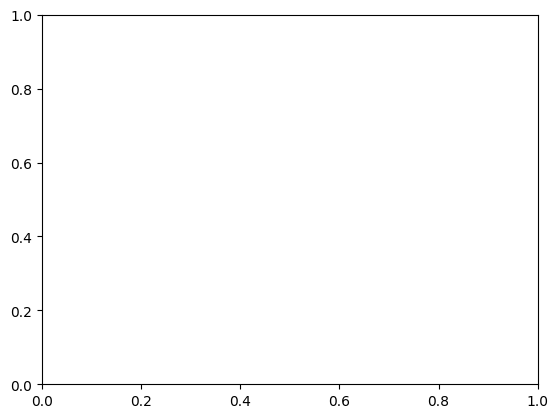

In [177]:
rep_with_gdp.filter(variable = 'Investment|Energy SupplY|Oil*',region = 'National', scenario = 'BAU').plot.stack(stack = 'variable')

/Users/muhammadawais/miniconda3/envs/msgca/lib/python3.11/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-CA scenario: netzero region: National'}, xlabel='Year', ylabel='billion US$2010/yr'>

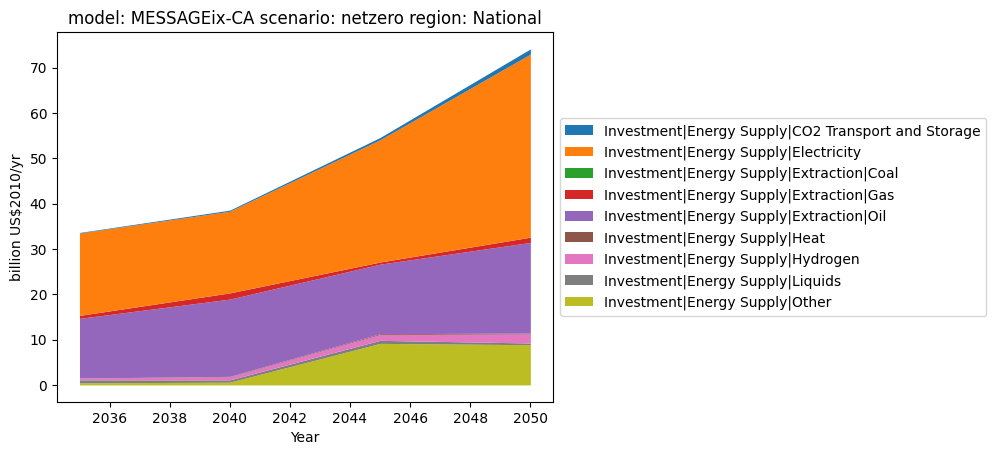

In [120]:
rep_with_gdp.filter(variable = variables, region = 'National',scenario = 'netzero',year = [2035,2040,2045,2050]).plot.stack(stack = 'variable')

[WARNING] 01:44:30 - pyam.core: Filtered IamDataFrame is empty!


IndexError: positional indexers are out-of-bounds

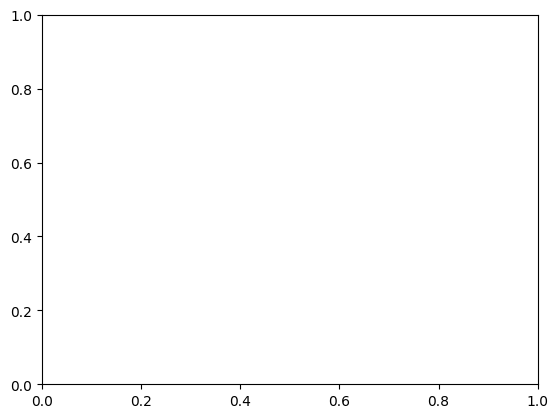

In [121]:
rep_with_gdp.filter(variable = variables, region = 'National',scenario = 'current measures',year = [2030,2035,2040,2045,2050]).plot.stack(stack = 'variable')

/Users/muhammadawais/miniconda3/envs/msg/lib/python3.11/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-CA scenario: NZ region: National'}, xlabel='Year', ylabel='billion US$2010/yr'>

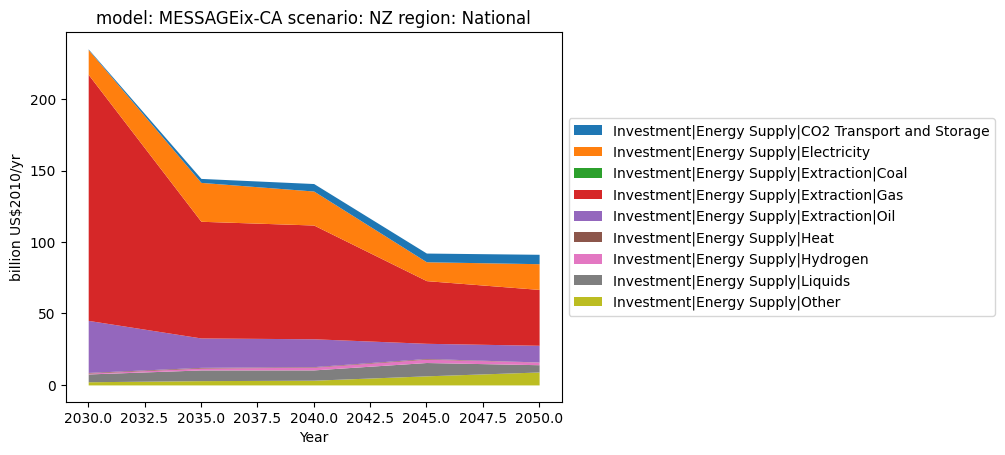

In [92]:
rep_with_gdp.filter(variable = variables, region = 'National',scenario = 'NZ',year = [2030,2035,2040,2045,2050]).plot.stack(stack = 'variable')

In [95]:
rep_with_gdp.filter(variable = variables).timeseries().to_csv('investments.csv')

/Users/muhammadawais/miniconda3/envs/msg/lib/python3.11/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-CA scenario: NZ-PES region: National'}, xlabel='Year', ylabel='billion US$2010/yr'>

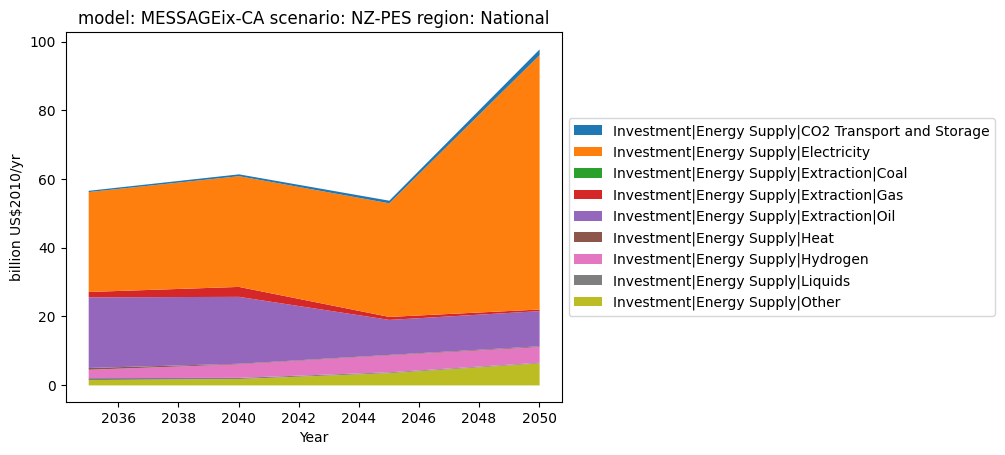

In [90]:
rep_with_gdp.filter(variable = variables, region = 'National',scenario = 'NZ-PES',year = [2035,2040,2045,2050]).plot.stack(stack = 'variable')

/Users/muhammadawais/miniconda3/envs/msg/lib/python3.11/site-packages/pyam/plotting.py:461: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  _rows = pd.concat(
/Users/muhammadawais/miniconda3/envs/msg/lib/python3.11/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-CA scenario: BAU region: National'}, xlabel='Year', ylabel='PJ/yr'>

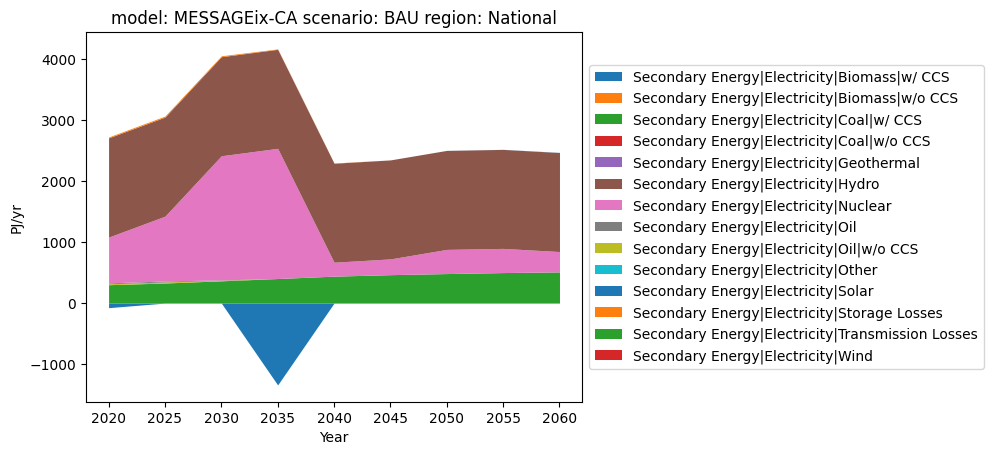

In [119]:
rep_with_gdp.filter(variable = variables, scenario = 'BAU',region = 'National').plot.stack(stack = 'variable')

In [ ]:
import pandas as pd

# Define the regex pattern for matching
pattern = r'^Emissions\|Kyoto Gases.*$'

# Create a boolean mask for rows matching the pattern and Scenario 'BAU'
mask = df.index.to_series().str.match(pattern) & (df['Scenario'] == 'BAU')

# Assign the new values to '2030' and '2035' columns for the filtered rows
df.loc[mask, ['2030', '2035']] = pd.Series({'2030': 999, '2035': 888})


In [ ]:

df.loc[('Emissions|Kyoto Gases*', ['2030', '2035']) & (df['Scenario'] == 'BAU')] = 



In [101]:
rep_with_gdp.filter(variable = 'Final Energy').timesseries()

AttributeError: 'IamDataFrame' object has no attribute 'timesseries'

In [92]:
rep_with_gdp.as_pandas()

,model,scenario,region,variable,unit,year,value
0,MESSAGEix-CA,BAU,Alberta,Capacity Additions|Electricity,GW/yr,2020,41.110868
1,MESSAGEix-CA,BAU,Alberta,Capacity Additions|Electricity,GW/yr,2025,3.681251
2,MESSAGEix-CA,BAU,Alberta,Capacity Additions|Electricity,GW/yr,2030,2.789795
3,MESSAGEix-CA,BAU,Alberta,Capacity Additions|Electricity,GW/yr,2035,4.637693
4,MESSAGEix-CA,BAU,Alberta,Capacity Additions|Electricity,GW/yr,2040,1.204153
...,...,...,...,...,...,...,...
1035850,MESSAGEix-CA,NZ-PES,Yukon,Water Withdrawal|Liquids|Oil,km3/yr,2040,0.000000
1035851,MESSAGEix-CA,NZ-PES,Yukon,Water Withdrawal|Liquids|Oil,km3/yr,2045,0.000000
1035852,MESSAGEix-CA,NZ-PES,Yukon,Water Withdrawal|Liquids|Oil,km3/yr,2050,0.000000
1035853,MESSAGEix-CA,NZ-PES,Yukon,Water Withdrawal|Liquids|Oil,km3/yr,2055,0.000000


In [93]:
rep_with_gdp.filter(variable = 'Emissions|Kyoto Gases', region = 'National').timeseries()

2020  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4559.882316   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr  4607.806699   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1702.728583   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1702.886202   

                                                                             2025  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4603.513836   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr  2085.045752   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1684.865746   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1685.003133   

                                                                             2030  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4161.533327   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr  1328.539783   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1029.399060   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr  1029.240876   

                                                                             2035  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4147.408447   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr   756.155448   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr   685.252623   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr   684.898335   

                                                                             2040  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4289.924388   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr   409.510328   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr   498.744685   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr   499.255623   

                                                                             2045  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4479.291308   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr   213.931342   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr   347.289213   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr   347.338992   

                                                                             2050  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4699.821356   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr    81.497840   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr   191.667671   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr   191.667671   

                                                                             2055  \
model        scenario region   variable              unit                           
MESSAGEix-CA BAU      National Emissions|Kyoto Gases Mt CO2-equiv/yr  4931.994048   
             NZ       National Emissions|Kyoto Gases Mt CO2-equiv/yr    73.314819   
             NZ-OPT   National Emissions|Kyoto Gases Mt CO2-equiv/yr   190.271994   
             NZ-PES   National Emissions|Kyoto Gases Mt CO2-equiv/yr   190.

In [100]:
rep_with_gdp.filter(region = 'Alberta',variable = 'Final Energy').timeseries()

2020         2025  \
model        scenario region  variable     unit                              
MESSAGEix-CA BAU      Alberta Final Energy PJ/yr  3230.857405  4596.700394   
             NZ       Alberta Final Energy PJ/yr  3331.796368  4471.263653   
             NZ-OPT   Alberta Final Energy PJ/yr  3224.608048  4469.731443   
             NZ-PES   Alberta Final Energy PJ/yr  3224.608048  4469.185592   

                                                         2030         2035  \
model        scenario region  variable     unit                              
MESSAGEix-CA BAU      Alberta Final Energy PJ/yr  4602.008368  4613.746530   
             NZ       Alberta Final Energy PJ/yr  4268.165791  4277.382255   
             NZ-OPT   Alberta Final Energy PJ/yr  4317.513925  4161.420972   
             NZ-PES   Alberta Final Energy PJ/yr  4316.800594  4160.037151   

                                                         2040         2045  \
model        scenario region  variable     unit                              
MESSAGEix-CA BAU      Alberta Final Energy PJ/yr  4574.548430  4614.047949   
             NZ       Alberta Final Energy PJ/yr  4164.711336  4075.643059   
             NZ-OPT   Alberta Final Energy PJ/yr  3997.871067  3924.301398   
             NZ-PES   Alberta Final Energy PJ/yr  3998.725851  3924.847356   

                                                         2050         2055  \
model        scenario region  variable     unit                              
MESSAGEix-CA BAU      Alberta Final Energy PJ/yr  4691.430029  4810.769782   
             NZ       Alberta Final Energy PJ/yr  3601.912302  3984.155118   
             NZ-OPT   Alberta Final Energy PJ/yr  3510.453634  3934.199988   
             NZ-PES   Alberta Final Energy PJ/yr  3510.580330  3934.162542   

                                                         2060  
model        scenario region  variable     unit                
MESSAGEix-CA BAU      Alberta Final Energy PJ/yr  4959.276589  
             NZ       Alberta Final Energy PJ/yr  3508.992239  
             NZ-OPT   Alberta Final Energy PJ/yr  4415.521301  
             NZ-PES   Alberta Final Energy PJ/yr  4413.447118

In [ ]:

rep_with_gdp = pyam.concat([df_pyam,df_gdp])
rep_with_gdp.filter(variable ='Final Energy').convert_unit('PJ','MJ',factor = 1e-3)
# rep_with_gdp.filter(variable ='Final Energy').convert_unit('CAD','Bi-CAD',factor = 1e-9)
# Probably need to convert emissions from C-equivalent to CO2-equivalent?
#### ----- #### ---- #### ----- #### ---- #### ----- #### ---- #### ----- #### ---- ####
rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="National", subregions=rep_with_gdp.region, append=True)
rep_with_gdp.aggregate_region(variable=rep_with_gdp.variable, region="Atlantic", subregions=["PrinceEdwardIsland", "NovaScotia", "NewfoundlandandLabrador", "NewBrunswick"], append=True)


fin_energy = rep_with_gdp.divide('Final Energy','GDP','Final Energy Intensity of GDP',ignore_units=True, axis = 'variable').timeseries()
carbon_intensity = rep_with_gdp.divide('Emissions|Kyoto Gases','GDP','Carbon Intensity',ignore_units=True, axis = 'variable').timeseries()
second_energy_dem = rep_with_gdp.aggregate(variable="Final Energy Demand (Secondary Energy)",components=['Secondary Energy|Electricity', 'Secondary Energy|Gases', 'Secondary Energy|Heat'
                    'Secondary Energy|Hydrogen', 'Secondary Energy|Liquids', 'Secondary Energy|Solids'], method="sum")
elec_supply = rep_with_gdp.aggregate(variable = "Electricity Supply", components=["Secondary Energy|Electricity"])
elec_supply.convert_unit("PJ", "TWh", factor=0.2778)
# shadow_co2 = 
ghg_emissions = rep_with_gdp.aggregate(variable="Total GHG Emissions", components=["Emissions"])
ghg_emissions.convert_unit("Mt C-equivalent", "Mt CO2 eq", 44/12) 




In [ ]:


final_df = pyam.concat([rep_with_gdp, fin_energy, carbon_intensity, second_energy_dem, elec_supply, ghg_emissions])

final_df.to_csv("model/output/reports/Formatted_Report.csv")

# For searching up 
df_pyam.filter(variable = 'Emissions|*').variable

#Technology Learning Rates

In [3]:
dfnormal = pd.read_csv('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/scenarios/baseline/inv_cost_baseline.csv')
dfhigh = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/scenarios/netzero_opt/Inv_cost_high_LR.xlsx')
dflow = pd.read_excel('/Users/muhammadawais/Documents/GitHub/message-ix-canada/model/scenarios/netzero_pes/Inv_cost_low_LR.xlsx')

dfhigh = dfhigh[(dfhigh['node_loc'] == 'Alberta')]
dflow = dflow[(dflow['node_loc'] == 'Alberta')]

In [4]:
tecs = dflow['technology'].unique()

In [5]:
# dfnormal = dfnormal[(dfnormal['node_loc'] == 'Alberta') & dfnormal[dfnormal['technology'].isin(tecs)]]
dfhigh = dfhigh[(dfhigh['node_loc'] == 'Alberta')]
dflow = dflow[(dflow['node_loc'] == 'Alberta')]

In [6]:
dfnormal = dfnormal[(dfnormal['node_loc'] == 'Alberta') & (dfnormal['technology'].isin(tecs))]

In [149]:
dfnormal.to_csv('inv_cost_normal.csv')

In [40]:
import matplotlib.pyplot as plt
# Filter data for Alberta and calculate learning rates for all three datasets
low_lr_data = dflow
normal_lr_data = dfnormal
high_lr_data = dflow  # Already filtered

In [33]:
low_lr_data['technology'].unique()

array(['bio_istig_ccs', 'coal_adv_ccs', 'eth_bio_ccs', 'gas_cc_ccs',
       'gas_h2', 'H2 ATR', 'H2 ATR w/CCS', 'H2-BioGas-CCS',
       'H2-BioGas-CCS w/CCS', 'H2 CoalGas', 'H2 Electrolyzer',
       'h2_fc_trp', 'H2 FC Transport', 'H2 SMR', 'H2 SMR w/CCS',
       'h2_stor_geo', 'igcc_ccs', 'liq_bio_ccs', 'liq_h2',
       'meth_coal_ccs', 'meth_h2', 'meth_ng_ccs', 'syn_liq_ccs'],
      dtype=object)

In [34]:

# Define a mapping for renaming technologies
technology_name_map = {
    'h2_atr': 'H2 ATR',
    'h2_smr': 'H2 SMR',
    'h2_atr_ccs': 'H2 ATR w/CCS',
    'h2_smr_ccs': 'H2 SMR w/CCS',
    'h2_elec':'H2 Electrolyzer',
    'h2_gas_fc_trp':'H2 FC Transport',
    'h2_bio':'H2-BioGas-CCS',
    'h2_bio_ccs':'H2-BioGas-CCS w/CCS',
    'h2_coal':'H2 CoalGas',
    'h2_coal_ccs':'H2-BioGas-CCS w/CCS',
    
    # Add other mappings as needed
}

def rename_technologies(data, mapping):
    """
    Rename technologies in the dataset using the provided mapping.
    """
    data['technology'] = data['technology'].replace(mapping)
    return data

low_lr_data = rename_technologies(low_lr_data, technology_name_map)
normal_lr_data = rename_technologies(normal_lr_data, technology_name_map)
high_lr_data = rename_technologies(high_lr_data, technology_name_map)

In [ ]:
def handle_duplicates(data):
    """
    Remove duplicates or aggregate values for duplicate entries.
    """
    # Aggregate values for duplicates by taking the mean
    data = data.groupby(['year_vtg', 'technology'], as_index=False).mean()
    return data

# Apply the function to remove duplicates
h2_low = handle_duplicates(h2_low)
h2_normal = handle_duplicates(h2_normal)
h2_high = handle_duplicates(h2_high)

# Pivot data for plotting
h2_low_pivot = h2_low.pivot(index='year_vtg', columns='technology', values='rate_of_change')
h2_normal_pivot = h2_normal.pivot(index='year_vtg', columns='technology', values='rate_of_change')
h2_high_pivot = h2_high.pivot(index='year_vtg', columns='technology', values='rate_of_change')


In [39]:
tecs = [
    'H2 ATR',
    'H2 SMR',
    'H2 ATR w/CCS',
    'H2 SMR w/CCS',
    'H2 Electrolyzer',
    'H2 FC Transport',
    'H2-BioGas-CCS',
    'H2-BioGas-CCS w/CCS',
    'H2 CoalGas',
    'H2-BioGas-CCS w/CCS'
]


In [44]:
low_lr_data['technology'].unique()

array(['bio_istig_ccs', 'coal_adv_ccs', 'eth_bio_ccs', 'gas_cc_ccs',
       'gas_h2', 'H2 ATR', 'H2 ATR w/CCS', 'H2-BioGas-CCS',
       'H2-BioGas-CCS w/CCS', 'H2 CoalGas', 'H2 Electrolyzer',
       'h2_fc_trp', 'H2 FC Transport', 'H2 SMR', 'H2 SMR w/CCS',
       'h2_stor_geo', 'igcc_ccs', 'liq_bio_ccs', 'liq_h2',
       'meth_coal_ccs', 'meth_h2', 'meth_ng_ccs', 'syn_liq_ccs'],
      dtype=object)

In [45]:
import pandas as pd
import matplotlib.pyplot as plt



def calculate_learning_rate_from_base_fixed(data, base_year=2020):
    """
    Calculate rate of change relative to a base year for each technology,
    ensuring only unique base year values are used and handling missing base values.
    """
    # Extract base year values for unique technologies
    base_values = data[data['year_vtg'] == base_year].drop_duplicates('technology').set_index('technology')['value']
    
    # Debug: Ensure base_values is not empty
    if base_values.empty:
        raise ValueError(f"No base year data found for year {base_year}. Check the input data.")

    # Merge base year values into the main DataFrame
    data = data.merge(base_values.rename('base_value'), on='technology', how='left')
    
    # Debug: Check if base_value column exists after merging
    if 'base_value' not in data.columns:
        raise KeyError("Column 'base_value' is missing after the merge operation.")
    
    # Calculate rate of change, handling missing base_value entries
    data['rate_of_change'] = (data['value'] - data['base_value']) / data['base_value']
    
    # Fill NaN values in rate_of_change for rows without base_value
    data['rate_of_change'].fillna(0, inplace=True)
    
    return data

# Recalculate learning rates for low, normal, and high learning rates
try:
    low_lr_data = calculate_learning_rate_from_base_fixed(low_lr_data)
    normal_lr_data = calculate_learning_rate_from_base_fixed(normal_lr_data)
    high_lr_data = calculate_learning_rate_from_base_fixed(high_lr_data)
except Exception as e:
    print(f"An error occurred: {e}")


# Proceed with filtering and plotting as described in the previous complete code.

# Filter CCS and H2 technologies

tecs = ['h2_atr', 'h2_atr_ccs', 'h2_bio', 'h2_bio_ccs',
       'h2_coal', 'h2_coal_ccs', 'h2_elec', 'h2_gas_fc_trp']

tecs = [
    'H2 ATR',
    'H2 SMR',
    'H2 ATR w/CCS',
    'H2 SMR w/CCS',
    'H2 Electrolyzer',
    'H2 FC Transport',
    'H2-BioGas-CCS',
    'H2-BioGas-CCS w/CCS',
    'H2 CoalGas',
    'H2-BioGas-CCS w/CCS'
]


h2_low = low_lr_data[low_lr_data['technology'].isin(tecs)]
h2_normal = normal_lr_data[normal_lr_data['technology'].isin(tecs)]
h2_high = high_lr_data[high_lr_data['technology'].isin(tecs)]

# Pivot data for plotting
h2_low_pivot = h2_low.pivot(index='year_vtg', columns='technology', values='rate_of_change')
h2_normal_pivot = h2_normal.pivot(index='year_vtg', columns='technology', values='rate_of_change')
h2_high_pivot = h2_high.pivot(index='year_vtg', columns='technology', values='rate_of_change')

# Filter data starting from 2025

h2_low_pivot = h2_low_pivot.loc[h2_low_pivot.index >= 2025]
h2_normal_pivot = h2_normal_pivot.loc[h2_normal_pivot.index >= 2025]
h2_high_pivot = h2_high_pivot.loc[h2_high_pivot.index >= 2025]

# Define line styles and colors
line_styles = {'Low': 'dotted', 'Normal': 'solid', 'High': 'dashed'}
colors = plt.cm.tab10.colors  # Use consistent colors for technologies


# # Plot for CCS technologies
# plot_learning_rates_with_separate_legend(
#     [ccs_low_pivot, ccs_normal_pivot, ccs_high_pivot],
#     ['Low', 'Normal', 'High'],
#     'Learning Rates for CCS Technologies in Alberta (from 2025, Relative to 2020)'
# )

# # Plot for H2 technologies
# plot_learning_rates_with_separate_legend(
#     [h2_low_pivot, h2_normal_pivot, h2_high_pivot],
#     ['Low', 'Normal', 'High'],
#     'Learning Rates for H2 Technologies in Alberta (from 2025, Relative to 2020)'
# )

# Function for normal learning rates only
def plot_normal_learning_rates(pivot, title):
    plt.figure(figsize=(12, 6))
    tech_color_map = {}
    
    for tech in pivot.columns:
        if tech not in tech_color_map:
            tech_color_map[tech] = colors[len(tech_color_map) % len(colors)]
        plt.plot(
            pivot.index,
            pivot[tech],
            linestyle='solid',
            color=tech_color_map[tech],
            label=tech
        )
    
    plt.legend(loc='upper left', title='Technologies')
    plt.grid(True)
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Learning Rate (Rate of Change)')
    plt.tight_layout()
    plt.show()

# # Plot for CCS technologies with normal learning rate
# plot_normal_learning_rates(
#     ccs_normal_pivot,
#     'Learning Rates for CCS Technologies (Normal LR) in Alberta (from 2025, Relative to 2020)'
# )

# Plot for H2 technologies with normal learning rate
plot_normal_learning_rates(
    h2_normal_pivot,
    'Learning Rates for H2 Technologies (Normal LR) in Alberta (from 2025, Relative to 2020)'
)


An error occurred: "Column 'base_value' is missing after the merge operation."


ValueError: Index contains duplicate entries, cannot reshape

In [48]:
h2_normal.to_csv('h2_change.csv')

In [42]:
h2_normal

,node_loc,technology,year_vtg,value,unit,base_value,rate_of_change


In [ ]:

# Function to plot learning rates with separate legends
def plot_learning_rates_with_separate_legend(pivots, labels, title):
    plt.figure(figsize=(12, 6))
    tech_color_map = {}
    tech_lines = []  # For technology legend
    line_type_lines = []  # For learning rate legend
    
    for i, (pivot, label) in enumerate(zip(pivots, labels)):
        for tech in pivot.columns:
            if tech not in tech_color_map:
                tech_color_map[tech] = colors[len(tech_color_map) % len(colors)]
                tech_lines.append(plt.Line2D([], [], color=tech_color_map[tech], label=tech))
            plt.plot(
                pivot.index,
                pivot[tech],
                linestyle=line_styles[label],
                color=tech_color_map[tech]
            )
        # Add learning rate line style legend once per label
        if label not in [handle.get_label() for handle in line_type_lines]:
            line_type_lines.append(
                plt.Line2D([], [], color='black', linestyle=line_styles[label], label=label)
            )
    
    # Add legends
    plt.legend(handles=tech_lines, loc='upper left', title='Technologies')
    plt.legend(handles=line_type_lines, loc='upper right', title='Learning Rate', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Learning Rate (Rate of Change)')
    plt.tight_layout()
    plt.show()

,node_loc,technology,year_vtg,value,unit,base_value,rate_of_change
45,Alberta,H2 ATR,2020,730.94,USD/kW,730.94,0.000000
46,Alberta,H2 ATR,2025,697.32,USD/kW,730.94,-0.045996
47,Alberta,H2 ATR,2030,663.70,USD/kW,730.94,-0.091991
48,Alberta,H2 ATR,2035,642.09,USD/kW,730.94,-0.121556
49,Alberta,H2 ATR,2040,620.48,USD/kW,730.94,-0.151120
...,...,...,...,...,...,...,...
139,Alberta,H2 SMR w/CCS,2040,1215.82,USD/kW,1339.00,-0.091994
140,Alberta,H2 SMR w/CCS,2045,1176.23,USD/kW,1339.00,-0.121561
141,Alberta,H2 SMR w/CCS,2050,1136.65,USD/kW,1339.00,-0.151120
142,Alberta,H2 SMR w/CCS,2055,1111.20,USD/kW,1339.00,-0.170127


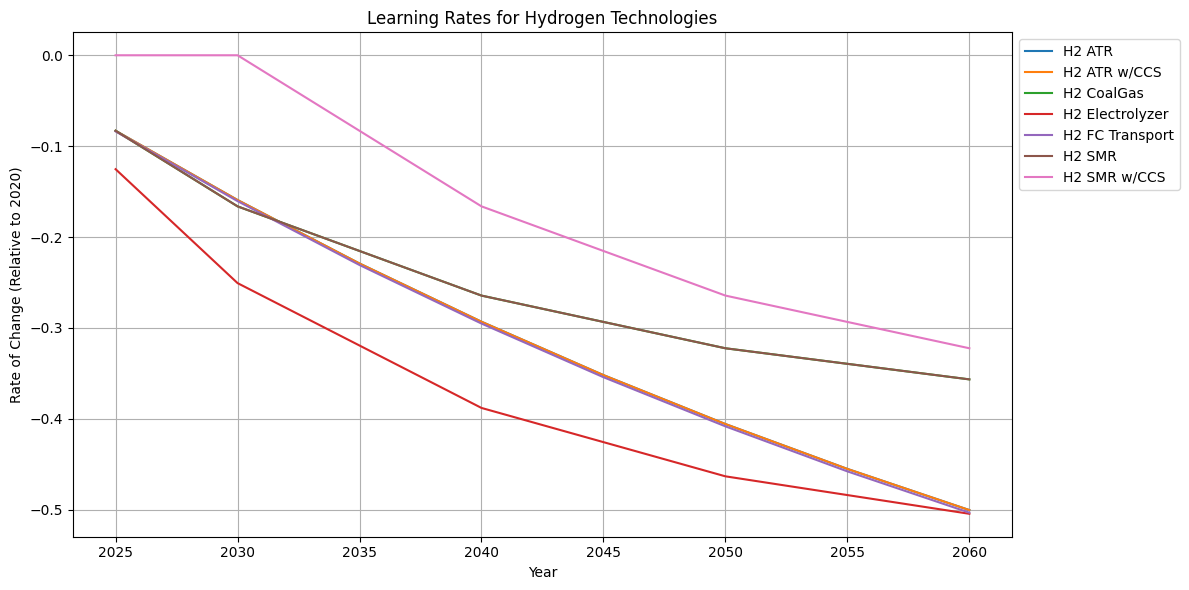

In [53]:
import pandas as pd
import matplotlib.pyplot as plt


h2_data = h2_normal

# Function to handle duplicates and aggregate only numeric columns
def handle_duplicates(data):
    """
    Remove duplicates or aggregate values for duplicate entries.
    """
    # Group by 'year_vtg' and 'technology', aggregating only numeric columns
    numeric_cols = data.select_dtypes(include='number').columns
    data = data.groupby(['year_vtg', 'technology'], as_index=False)[numeric_cols].mean()
    return data

# Apply the function to clean the data
h2_data_cleaned = handle_duplicates(h2_data)

# Filter out BioGas technologies
h2_data_filtered = h2_data_cleaned[~h2_data_cleaned['technology'].str.contains('BioGas', case=False)]

# Filter data starting from 2025
h2_data_filtered_2025 = h2_data_filtered[h2_data_filtered['year_vtg'] >= 2025]

# Pivot the filtered data for plotting
h2_pivot_filtered_2025 = h2_data_filtered_2025.pivot(index='year_vtg', columns='technology', values='rate_of_change')

# Plot the filtered data from 2025
plt.figure(figsize=(12, 6))
for technology in h2_pivot_filtered_2025.columns:
    plt.plot(h2_pivot_filtered_2025.index, h2_pivot_filtered_2025[technology], label=technology)

# Adding titles and labels
plt.title('Learning Rates for Hydrogen Technologies')
plt.xlabel('Year')
plt.ylabel('Rate of Change (Relative to 2020)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
h2_data_filtered_2025

,technology,year_vtg,value,base_value,rate_of_change
18,H2 ATR,2025.0,670.198886,730.94,-0.083100
19,H2 ATR w/CCS,2025.0,966.412600,1054.00,-0.083100
20,H2 CoalGas,2025.0,1950.180000,2127.00,-0.083131
21,H2 Electrolyzer,2025.0,979.600000,1120.00,-0.125357
22,H2 FC Transport,2025.0,1909.006875,2083.50,-0.083750
23,H2 SMR,2025.0,664.730000,725.00,-0.083131
24,H2 SMR w/CCS,2025.0,1339.000000,1339.00,0.000000
27,H2 ATR,2030.0,614.505359,730.94,-0.159294
28,H2 ATR w/CCS,2030.0,886.103713,1054.00,-0.159294
29,H2 CoalGas,2030.0,1773.350000,2127.00,-0.166267


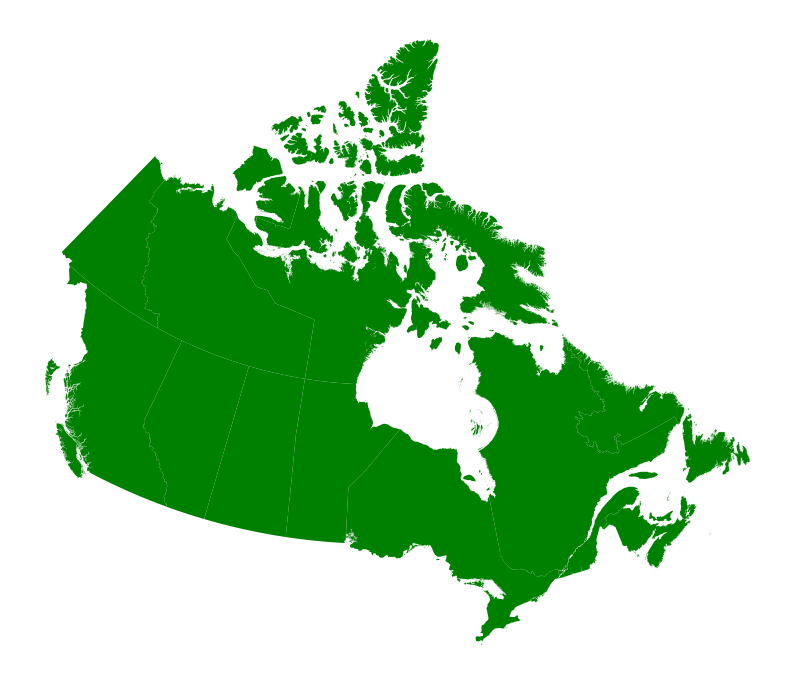

In [127]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pyam
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox
from matplotlib.transforms import Affine2D
from matplotlib import cm

# Path to your shapefile (make sure all required files are in the same directory)
shapefile_path = '/Users/muhammadawais/Documents/GitHub/message-ix-canada/data/delineation/lpr_000b16a_e.shp'

# Load the shapefile using geopandas
gdf = gpd.read_file(shapefile_path)

# Create a plot with light green color filling the geometries
ax = gdf.plot(figsize=(10, 10), color='green', edgecolor='none')

# Remove axis labels and ticks
ax.set_axis_off()

# Show the plot
plt.show()

In [12]:
rep_with_gdp.filter(variable = 'Investment').timeseries()

2020  \
model        scenario region                  variable   unit                             
MESSAGEix-CA BAU      Alberta                 Investment billion US$2010/yr   92.470985   
                      Atlantic                Investment billion US$2010/yr    2.969136   
                      BritishColumbia         Investment billion US$2010/yr   19.245484   
                      Manitoba                Investment billion US$2010/yr    1.067055   
                      National                Investment billion US$2010/yr  143.445200   
                      NewBrunswick            Investment billion US$2010/yr    0.766277   
                      NewfoundlandandLabrador Investment billion US$2010/yr    0.955722   
                      NorthwestTerritories    Investment billion US$2010/yr    0.058160   
                      NovaScotia              Investment billion US$2010/yr    1.174724   
                      Nunavut                 Investment billion US$2010/yr    0.133184   
                      Ontario                 Investment billion US$2010/yr    9.621797   
                      PrinceEdwardIsland      Investment billion US$2010/yr    0.072412   
                      Quebec                  Investment billion US$2010/yr   12.804803   
                      Saskatchewan            Investment billion US$2010/yr    5.065149   
                      Yukon                   Investment billion US$2010/yr    0.009448   
             NZ       Alberta                 Investment billion US$2010/yr  212.105272   
                      Atlantic                Investment billion US$2010/yr    3.012669   
                      BritishColumbia         Investment billion US$2010/yr   95.779727   
                      Manitoba                Investment billion US$2010/yr    2.070051   
                      National                Investment billion US$2010/yr  353.256536   
                      NewBrunswick            Investment billion US$2010/yr    0.790586   
                      NewfoundlandandLabrador Investment billion US$2010/yr    0.999108   
                      NorthwestTerritories    Investment billion US$2010/yr    0.086436   
                      NovaScotia              Investment billion US$2010/yr    1.159974   
                      Nunavut                 Investment billion US$2010/yr    0.123369   
                      Ontario                 Investment billion US$2010/yr   14.246298   
                      PrinceEdwardIsland      Investment billion US$2010/yr    0.063001   
                      Quebec                  Investment billion US$2010/yr   14.794105   
                      Saskatchewan            Investment billion US$2010/yr   11.023155   
                      Yukon                   Investment billion US$2010/yr    0.015454   
             NZ-OPT   Alberta                 Investment billion US$2010/yr   92.729062   
                      Atlantic                Investment billion US$2010/yr    3.006963   
                      BritishColumbia         Investment billion US$2010/yr   19.321228   
                      Manitoba                Investment billion US$2010/yr    1.072960   
                      National                Investment billion US$2010/yr  145.688967   
                      NewBrunswick            Investment billion US$2010/yr    0.807615   
                      NewfoundlandandLabrador Investment billion US$2010/yr    0.951644   
                      NorthwestTerritories    Investment billion US$2010/yr    0.131798   
                      NovaScotia              Investment billion US$2010/yr    1.175668   
                      Nunavut                 Investment billion US$2010/yr    0.189000   
                      Ontario                 Investment billion US$2010/yr   10.826037   
                      PrinceEdwardIsland      Investment billion US$2010/yr    0.072037   
                      Quebec                  Investment billion US$2010/yr   1

In [ ]:
rep_with_gdp.divide('Perc. of GDP','Investment','GDP',ignore_units = True)

In [13]:
df_inv = rep_with_gdp.filter(variable = ['Investment','GDP'])

In [14]:
df_inv_f = df_inv.filter(region = ['Atlantic','National'],keep = False)

In [107]:
1.19*1.34

1.5946

In [15]:
df_inv_f = df_inv_f.convert_unit('billion US$2010/yr','billion CAD2020$',factor = 1.5946)

In [24]:
df_inv_f.timeseries()

2020  \
model        scenario region             variable   unit                           
MESSAGEix-CA BAU      Alberta            GDP        billion CAD2020$  367.643507   
                                         Investment billion CAD2020$  147.454233   
                      BritishColumbia    GDP        billion CAD2020$  332.472267   
                                         Investment billion CAD2020$   30.688849   
                      Manitoba           GDP        billion CAD2020$   75.856805   
...                                                                          ...   
             NZ-PES   Ontario            Investment billion CAD2020$   17.263199   
                      PrinceEdwardIsland Investment billion CAD2020$    0.114870   
                      Quebec             Investment billion CAD2020$   21.267997   
                      Saskatchewan       Investment billion CAD2020$    8.076886   
                      Yukon              Investment billion CAD2020$    0.014763   

                                                                            2025  \
model        scenario region             variable   unit                           
MESSAGEix-CA BAU      Alberta            GDP        billion CAD2020$  407.805418   
                                         Investment billion CAD2020$  132.379449   
                      BritishColumbia    GDP        billion CAD2020$  368.452642   
                                         Investment billion CAD2020$    4.433501   
                      Manitoba           GDP        billion CAD2020$   84.149686   
...                                                                          ...   
             NZ-PES   Ontario            Investment billion CAD2020$    6.882219   
                      PrinceEdwardIsland Investment billion CAD2020$    0.184268   
                      Quebec             Investment billion CAD2020$    7.240332   
                      Saskatchewan       Investment billion CAD2020$    8.605631   
                      Yukon              Investment billion CAD2020$    0.041952   

                                                                            2030  \
model        scenario region             variable   unit                           
MESSAGEix-CA BAU      Alberta            GDP        billion CAD2020$  447.967329   
                                         Investment billion CAD2020$   72.073048   
                      BritishColumbia    GDP        billion CAD2020$  404.433017   
                                         Investment billion CAD2020$    5.237451   
                      Manitoba           GDP        billion CAD2020$   92.442566   
...                                                                          ...   
             NZ-PES   Ontario            Investment billion CAD2020$   16.670551   
                      PrinceEdwardIsland Investment billion CAD2020$    0.084080   
                      Quebec             Investment billion CAD2020$    8.435323   
                      Saskatchewan       Investment billion CAD2020$    5.678842   
                      Yukon              Investment billion CAD2020$    0.015317   

                                                                            2035  \
model        scenario region             variable   unit                           
MESSAGEix-CA BAU      Alberta            GDP        billion CAD2020$  494.432761   
                                         Investment billion CAD2020$   45.742131   
                      BritishColumbia    GDP        billion CAD2020$  445.098990   
                                         Investment billion CAD2020$    8.247699   
                      Manitoba           GDP        billion CAD2020$  101.981705   
...                                                                          ...   
             NZ-PES   Ontario            Investment billion CAD2020$   16.368003   
                      PrinceEdwardIsland 

In [21]:
df_inv_f = df_inv_f.convert_unit('CAD','billion CAD2020$',factor = 1e-09)

In [30]:
df_gdp = df_inv_f.filter(variable = 'GDP').timeseries()

In [32]:
df_gdp.reset_index(inplace = True)

In [34]:
df_gdp['scenario'] = 'NZ-OPT'

In [ ]:
df_gdp['']

,model,scenario,region,variable,unit,2020,2025,2030,2035,2040,2045,2050,2055,2060
0,MESSAGEix-CA,NZ-OPT,Alberta,GDP,billion CAD2020$,367.643507,407.805418,447.967329,494.432761,540.898193,589.402369,637.906544,688.642810,739.379075
1,MESSAGEix-CA,NZ-OPT,BritishColumbia,GDP,billion CAD2020$,332.472267,368.452642,404.433017,445.098990,485.764964,527.889734,570.014503,613.883980,657.753457
2,MESSAGEix-CA,NZ-OPT,Manitoba,GDP,billion CAD2020$,75.856805,84.149686,92.442566,101.981705,111.520844,121.435973,131.351102,141.714865,152.078627
3,MESSAGEix-CA,NZ-OPT,NewBrunswick,GDP,billion CAD2020$,38.034662,42.174695,46.314729,51.037187,55.759645,60.715790,65.671936,70.873201,76.074466
4,MESSAGEix-CA,NZ-OPT,NewfoundlandandLabrador,GDP,billion CAD2020$,31.648398,35.108863,38.569329,42.547566,46.525803,50.654220,54.782638,59.104924,63.427210
5,MESSAGEix-CA,NZ-OPT,NorthwestTerritories,GDP,billion CAD2020$,4.647090,5.160536,5.673983,6.261477,6.848972,7.461651,8.074330,8.711697,9.349063
6,MESSAGEix-CA,NZ-OPT,NovaScotia,GDP,billion CAD2020$,47.844067,53.050790,58.257512,64.085862,69.914212,75.924843,81.935475,88.122079,94.308684
7,MESSAGEix-CA,NZ-OPT,Nunavut,GDP,billion CAD2020$,4.229159,4.680983,5.132807,5.636030,6.139252,6.679329,7.219407,7.785095,8.350784
8,MESSAGEix-CA,NZ-OPT,Ontario,GDP,billion CAD2020$,932.204718,1032.961968,1133.719218,1247.548081,1361.376944,1479.559110,1597.741276,1720.887346,1844.033417
9,MESSAGEix-CA,NZ-OPT,PrinceEdwardIsland,GDP,billion CAD2020$,7.944404,8.807388,9.670372,10.672525,11.674679,12.723175,13.771672,14.878444,15.985216


In [36]:
df_invesment = df_inv_f.filter(variable = 'Investment', scenario = 'NZ-OPT').timeseries()

In [37]:

columns_till_2050 = [2025, 2030, 2035, 2040, 2045, 2050]
df_invesment['average'] = df_invesment[columns_till_2050].mean(axis=1)

In [38]:
df_invesment.reset_index(inplace = True)

In [40]:
df_gdp

,model,scenario,region,variable,unit,2020,2025,2030,2035,2040,2045,2050,2055,2060
0,MESSAGEix-CA,NZ-OPT,Alberta,GDP,billion CAD2020$,367.643507,407.805418,447.967329,494.432761,540.898193,589.402369,637.906544,688.642810,739.379075
1,MESSAGEix-CA,NZ-OPT,BritishColumbia,GDP,billion CAD2020$,332.472267,368.452642,404.433017,445.098990,485.764964,527.889734,570.014503,613.883980,657.753457
2,MESSAGEix-CA,NZ-OPT,Manitoba,GDP,billion CAD2020$,75.856805,84.149686,92.442566,101.981705,111.520844,121.435973,131.351102,141.714865,152.078627
3,MESSAGEix-CA,NZ-OPT,NewBrunswick,GDP,billion CAD2020$,38.034662,42.174695,46.314729,51.037187,55.759645,60.715790,65.671936,70.873201,76.074466
4,MESSAGEix-CA,NZ-OPT,NewfoundlandandLabrador,GDP,billion CAD2020$,31.648398,35.108863,38.569329,42.547566,46.525803,50.654220,54.782638,59.104924,63.427210
5,MESSAGEix-CA,NZ-OPT,NorthwestTerritories,GDP,billion CAD2020$,4.647090,5.160536,5.673983,6.261477,6.848972,7.461651,8.074330,8.711697,9.349063
6,MESSAGEix-CA,NZ-OPT,NovaScotia,GDP,billion CAD2020$,47.844067,53.050790,58.257512,64.085862,69.914212,75.924843,81.935475,88.122079,94.308684
7,MESSAGEix-CA,NZ-OPT,Nunavut,GDP,billion CAD2020$,4.229159,4.680983,5.132807,5.636030,6.139252,6.679329,7.219407,7.785095,8.350784
8,MESSAGEix-CA,NZ-OPT,Ontario,GDP,billion CAD2020$,932.204718,1032.961968,1133.719218,1247.548081,1361.376944,1479.559110,1597.741276,1720.887346,1844.033417
9,MESSAGEix-CA,NZ-OPT,PrinceEdwardIsland,GDP,billion CAD2020$,7.944404,8.807388,9.670372,10.672525,11.674679,12.723175,13.771672,14.878444,15.985216


In [44]:
df_merge = df_invesment.merge(df_gdp, on = ['region','model','scenario','unit'])

In [45]:
df_merge

,model,scenario,region,variable_x,unit,2020_x,2025_x,2030_x,2035_x,2040_x,...,variable_y,2020_y,2025_y,2030_y,2035_y,2040_y,2045_y,2050_y,2055_y,2060_y
0,MESSAGEix-CA,NZ-OPT,Alberta,Investment,billion CAD2020$,147.865763,132.034155,69.941757,45.913849,42.490284,...,GDP,367.643507,407.805418,447.967329,494.432761,540.898193,589.402369,637.906544,688.642810,739.379075
1,MESSAGEix-CA,NZ-OPT,BritishColumbia,Investment,billion CAD2020$,30.809630,4.562492,4.846734,8.465997,6.577280,...,GDP,332.472267,368.452642,404.433017,445.098990,485.764964,527.889734,570.014503,613.883980,657.753457
2,MESSAGEix-CA,NZ-OPT,Manitoba,Investment,billion CAD2020$,1.710941,1.696866,1.731219,1.310360,2.039656,...,GDP,75.856805,84.149686,92.442566,101.981705,111.520844,121.435973,131.351102,141.714865,152.078627
3,MESSAGEix-CA,NZ-OPT,NewBrunswick,Investment,billion CAD2020$,1.287822,1.721675,1.694609,1.455712,0.836445,...,GDP,38.034662,42.174695,46.314729,51.037187,55.759645,60.715790,65.671936,70.873201,76.074466
4,MESSAGEix-CA,NZ-OPT,NewfoundlandandLabrador,Investment,billion CAD2020$,1.517491,2.232980,1.326681,1.294530,0.875377,...,GDP,31.648398,35.108863,38.569329,42.547566,46.525803,50.654220,54.782638,59.104924,63.427210
5,MESSAGEix-CA,NZ-OPT,NorthwestTerritories,Investment,billion CAD2020$,0.210166,0.364949,0.545048,0.218071,0.116088,...,GDP,4.647090,5.160536,5.673983,6.261477,6.848972,7.461651,8.074330,8.711697,9.349063
6,MESSAGEix-CA,NZ-OPT,NovaScotia,Investment,billion CAD2020$,1.874720,2.728555,3.360900,2.370779,1.359687,...,GDP,47.844067,53.050790,58.257512,64.085862,69.914212,75.924843,81.935475,88.122079,94.308684
7,MESSAGEix-CA,NZ-OPT,Nunavut,Investment,billion CAD2020$,0.301379,0.118428,0.189816,0.045042,0.036398,...,GDP,4.229159,4.680983,5.132807,5.636030,6.139252,6.679329,7.219407,7.785095,8.350784
8,MESSAGEix-CA,NZ-OPT,Ontario,Investment,billion CAD2020$,17.263199,6.879497,16.630517,16.208036,26.062072,...,GDP,932.204718,1032.961968,1133.719218,1247.548081,1361.376944,1479.559110,1597.741276,1720.887346,1844.033417
9,MESSAGEix-CA,NZ-OPT,PrinceEdwardIsland,Investment,billion CAD2020$,0.114870,0.184215,0.084106,0.175447,0.280489,...,GDP,7.944404,8.807388,9.670372,10.672525,11.674679,12.723175,13.771672,14.878444,15.985216


In [49]:
df_merge['percgdp2020'] = (df_merge['average']/df_merge['2020_y'])*100

In [50]:
df_merge['percgdp2020']


0     18.137373
1      1.605488
2      2.336270
3      3.794986
4      4.601903
5      6.935072
6      4.436570
7      2.673041
8      2.604727
9      2.500769
10     1.901214
11     6.519745
12     1.196150
Name: percgdp2020, dtype: float64

/var/folders/kp/fywbc9rj4lld_vk6pm6m71g00000gn/T/ipykernel_73331/2060697988.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot.rename(columns = {'percgdp2020':'value'}, inplace = True)
/var/folders/kp/fywbc9rj4lld_vk6pm6m71g00000gn/T/ipykernel_73331/2060697988.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


In [ ]:
# Update the plot with larger legend text size for better readability
fig, ax = plt.subplots(figsize=(16, 12), dpi=300)

pivot_data_filtered.plot(kind='barh', ax=ax, width=0.8, stacked=False)

# Customize the plot
ax.set_title('Avg. Annual Energy Supply Investments (2030-2050)', fontsize=18)
ax.set_xlabel('Investment (billion CAD2020$/yr)', fontsize=14)
ax.set_ylabel('Energy Supply Type', fontsize=14)
ax.legend(title='Scenario', fontsize=16, title_fontsize=16)
ax.tick_params(axis='y', labelsize=14, rotation=0)
ax.tick_params(axis='x', labelsize=14)

# Save the updated plot with improved legend text size
plt.tight_layout()
plt.savefig('/mnt/data/high_res_energy_investment_plot_updated.png', format='png', dpi=300)
plt.show()


In [ ]:
# Re-importing necessary libraries and reloading data as the environment has been reset
import pandas as pd
import matplotlib.pyplot as plt

# Re-load the provided CSV file
file_path = '/mnt/data/plot_inv.csv'
data = pd.read_csv(file_path)

# Simplify the variable names for meaningful legends
data['variable'] = data['variable'].str.replace('Investment|Energy Supply|', '', regex=False)
data['variable'] = data['variable'].str.replace('Extraction|', '', regex=False)
data['variable'] = data['variable'].str.replace('CO2 Transport and Storage', 'CO2 Storage', regex=False)
data['variable'] = data['variable'].str.replace('|', ' ', regex=False).str.strip()

# Filter the data to include only the specified scenarios
filtered_data = data[data['scenario'].isin(['BAU', 'NZ-OPT'])]

# Update the scenario names for meaningful labels
filtered_data['scenario'] = filtered_data['scenario'].replace({'BAU': 'Legislated', 'NZ-OPT': 'Net Zero'})

# Prepare data for stacked bar charts
stacked_data = filtered_data.pivot_table(
    index='variable', columns='scenario', values='value', aggfunc='sum'
)

# Transpose for better visualization in stacked bar chart
stacked_data = stacked_data.T

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

stacked_data.plot(kind='bar', stacked=True, ax=ax, width=0.8)

# Customize the plot
ax.set_title('Avg. Annual Energy Supply Investments (2030-2050)', fontsize=16)
ax.set_ylabel('Investment (billion CAD2020$/yr)', fontsize=14)
ax.set_xlabel('Scenario', fontsize=14)
ax.legend(title='Energy Supply Type', fontsize=12, title_fontsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Save the stacked bar chart as a high-resolution image
plt.tight_layout()
plt.savefig('/mnt/data/energy_investment_stacked_bar.png', format='png', dpi=300)
plt.show()
